---
title: 6 Structural differences between switching isoforms <br> (Figure 3e-f)
subtitle: Compare isoforms that are switching in dominance between protocols
jupyter: analysis-pages
execute:
  cache: false
author: Rotem Aharon
date: today
date-format: long
---



## Setup imports and parameters {.unnumbered .unlisted}

In [1]:
import sys
sys.path.append(
    "/Users/rotem/Code/manuscript-and-analysis-code/src/python")

In [2]:
import matplotlib.pyplot as plt
from math import nan
import os
import plotnine as p9
import matplotlib
import logging
import transparent
import pandas as pd
import numpy as np

In [3]:
# | warning: false

# Example for a single contrast
cell_line = "A549"
assay = "counts"
contrast_name = "dRNAvsPCRcDNA"
case_name = cell_line + assay + contrast_name


project_path = "/Users/rotem/Code/manuscript-and-analysis-code/"
data_path = "../../data/"
output_path = "../../data/analysis_output/ont_only_counts/"
figures_path = "figures/"


output_prefix = "data/analysis_output/ont_only_counts/"
figures_prefix = "figures/"
publication_figures = "manuscript/figures/"

bambu_ann_filename = "bambu_output/ont_only_counts/extended_annotations.gtf"
ann_path = data_path + bambu_ann_filename  # "bambu/extended_annotations.gtf"
cpm = "bambu_output/ont_only_counts/CPM_transcript.txt"
cpm_file_path = data_path + cpm  # "/Users/aharonrotem/Projects/LongReads/data/

# Obtain structural difference between ref and test (all cell-lines)

- In DTU genes with dominant isoform switching between protocols
- In background (nonDTU) genes

In [4]:
# | warning: false
i = 0

collect_results = pd.DataFrame()
sqanti_labels_to_plot = pd.DataFrame()

for cell_line in ["A549",  "H9", "Hct116", "HepG2", "HEYA8",  "K562", "MCF7"]:

    case_name = cell_line + contrast_name
    proportions_path = project_path + output_prefix + "proportions/" + \
        cell_line + "_" + assay + "_" + "proportions.csv"

    case_name = cell_line + "counts" + contrast_name

    proportions_path = output_path + "proportions/singleContrast" + \
        cell_line + "_" + assay + "_" + "proportions.csv"

    pairs_path = project_path + output_prefix + "isoform_pairs/" + \
        case_name + "novelIsoformPairs.csv"  # "isoformPairs.csv"


# ====================

    pairs_suffix = "test_new_isoformPairsAfterFilters.csv"

    pairs_path = project_path + output_prefix + "isoform_pairs/" + \
        case_name + pairs_suffix

    sqanti3_results_path = project_path + \
        "data/analysis_output/ont_only_counts/SQANTI3_output/" + \
        case_name + "_test_new_switchingIsoforms_asRef_asRef/"

   # test_sqanti_path = project_path + output_prefix + \
    #    "SQANTI3_output/" + case_name + "_test_new_switchingIsoforms_asRef_asRef/"
    # sqanti3_results_file = miss_case_name + \
    #   "_test_new_switchingIsoforms_tx2label_classification.txt"

    # TESTS NEW RESULTS PATH AND FILENAME
    # sqanti3_results_path = test_sqanti_path
    sqanti3_results_file = case_name + \
        "_test_new_switchingIsoforms_tx2label_classification.txt"
    # transcript_pairs = isoformPairs(
    #        proportions_path, ann_path, cpm_file_path,DTU=True,given_pairs=pairs_path )

    run_transcript_pairs = transparent.runTranscriptPairs(
        annotation_path=ann_path, pairs_path=pairs_path, proportions_path=proportions_path)
    # transcript_pairs.analyseArtefacts()
    transcript_pairs = run_transcript_pairs.transcript_pairs
    # Comment these lines out just for now to make it easier to add the switching pairs after the new filter

    transcript_pairs.SQANTI3_labels = sqanti3_results_path+sqanti3_results_file
    # transcript_pairs.integrateSQANTI

    # transcript_pairs.integrateSQANTI3labels(
    #     sqanti3_results_path+sqanti3_results_file)

    # switching_pairs = transcript_pairs.add_gffcompare_results(gffcompare_results_path,sqanti3_intersect = True)

    switching_pairs = transcript_pairs.transcript_pairs
    switching_pairs["cell_line"] = cell_line
    switching_pairs["pair_label"] = "Switching isoforms"

    df_pairs = pd.read_csv(pairs_path)

    switching_pairs = pd.merge(
        left=switching_pairs,
        right=df_pairs[['geneID',  'mean_expression.x']],
        how='left',
        left_on='gene_id',
        right_on='geneID')

    # print(switching_pairs.shape)
    collect_results = pd.concat([collect_results, switching_pairs])

    transcript_pairs.SQANTI3_labels["pairs"] = "isoform_switching"
    transcript_pairs.SQANTI3_labels["cell_line"] = cell_line

    sqanti_labels_to_plot = pd.concat(
        [sqanti_labels_to_plot, transcript_pairs.SQANTI3_labels])

    # ===============  get background pairs ==================================

    background_pairs_path = project_path + output_prefix + \
        "isoform_pairs/" + case_name + "backgroud_pairs.csv"

    # need to fix this df for now but should solve later to make column names consistent for all filter functions. Make them more generic - like ref and test or something instead of as it is atm.
    df = pd.read_csv(background_pairs_path)
    df.columns = df.columns.str.replace('.plusGroupTopTx', '.plusGroupHigh')
    df.columns = df.columns.str.replace('.plusGroup2ndTx', '.minusGroupHigh')

    df.to_csv(background_pairs_path)

    run_background_transcripts = transparent.runTranscriptPairs(
        annotation_path=ann_path, pairs_path=background_pairs_path, proportions_path=proportions_path)

    background_transcript_pairs = run_background_transcripts.transcript_pairs
    background_pairs = background_transcript_pairs.transcript_pairs
    background_pairs["cell_line"] = cell_line
    background_pairs["pair_label"] = "Background isoforms"

    background_pairs = pd.merge(
        left=background_pairs,
        right=df[['geneID',  'mean_expression.x']],
        how='left',
        left_on='gene_id',
        right_on='geneID')
# print(background_pairs.shape)
    collect_results = pd.concat([collect_results, background_pairs])

    i = i+1

/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping

# Summary plots

## SQANTI3 labels (Figure 3f)

In [5]:
SQANTIlabel_color_dict = {'full-splice_match': '#1f77b4',
                          'genic': '#9467bd',
                          'incomplete-splice_match': '#ff7f0e',
                          'intergenic':  '#7f7f7f',
                          'novel_in_catalog': '#2ca02c',
                          'novel_not_in_catalog': '#d62728'}

SQANTIlabel_color_dict = {'full-splice_match': '#51a7d9',
                          'incomplete-splice_match': '#f1895d',
                          'genic': '#75479b',
                          'intergenic':  '#a6a8aa',
                          'novel_in_catalog': '#67b77c',
                          'novel_not_in_catalog': '#e96a52'}

In [6]:
sqanti_labels_to_plot["ordered_structural_category"] = pd.Categorical(sqanti_labels_to_plot.structural_category,
                                                                      categories=SQANTIlabel_color_dict.keys(), ordered=True)

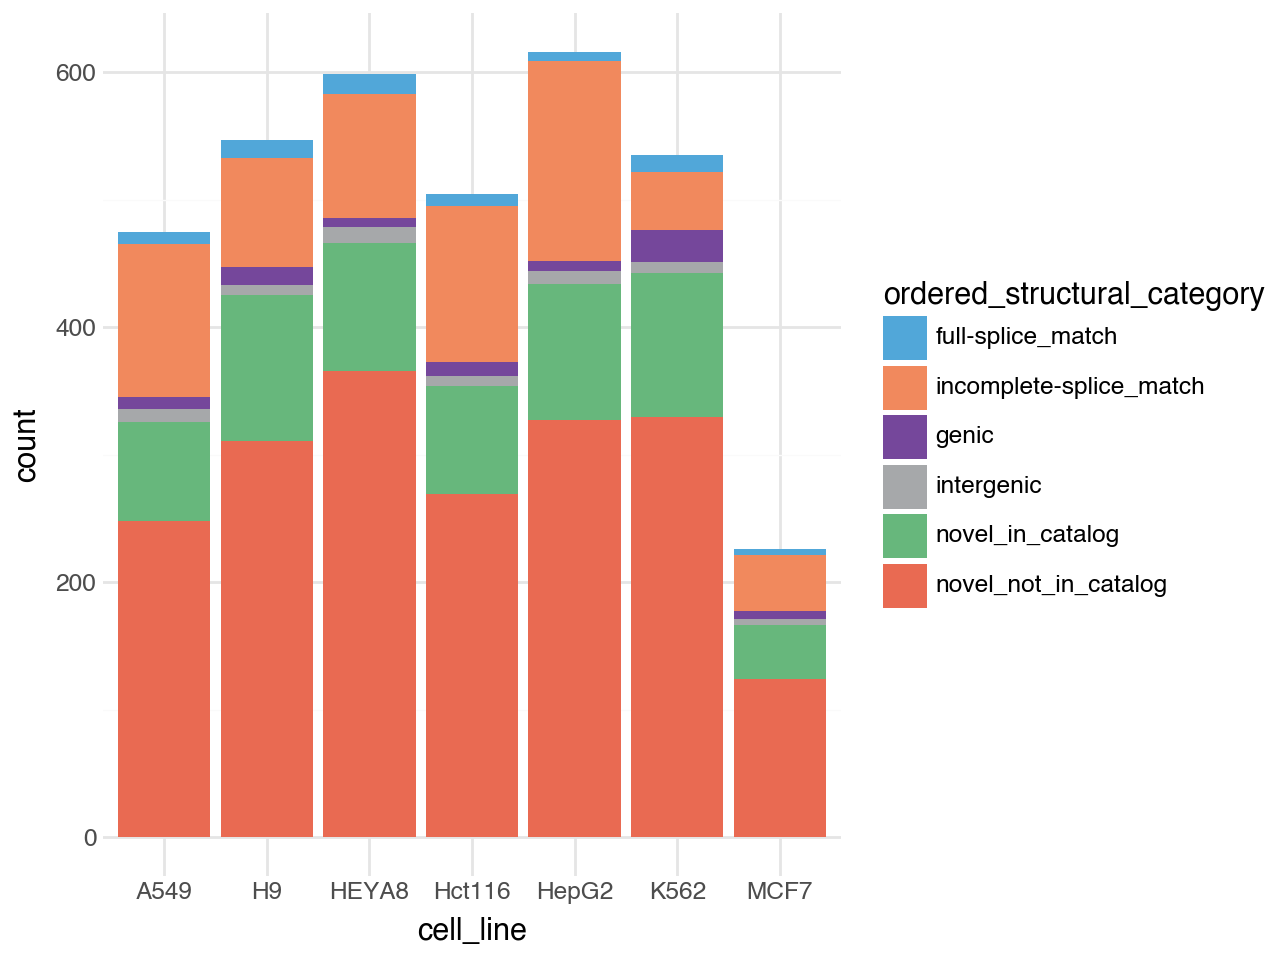

In [7]:
sqanti_labels = (p9.ggplot(sqanti_labels_to_plot,
                           p9.aes(x="cell_line",
                                  fill="ordered_structural_category")) +
                 p9.geom_bar(stat="count") + p9.scale_fill_manual(values=SQANTIlabel_color_dict) + p9.theme(legend_position="bottom")) + p9.theme_minimal()


sqanti_labels

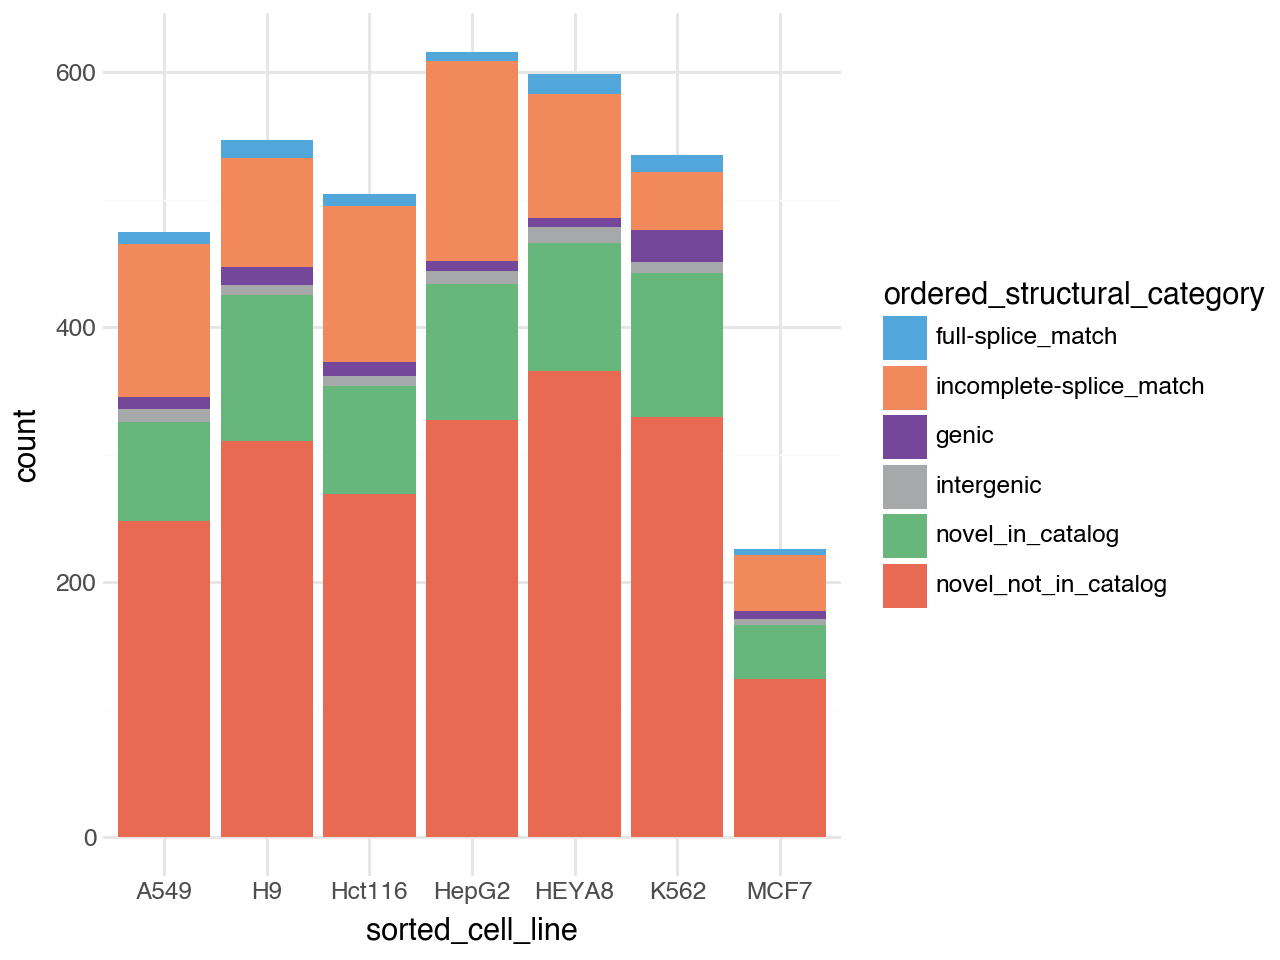

In [8]:

# 1. Sort the unique values alphabetically
sorted_categories = ["A549",  "H9", "Hct116",
                     "HepG2", "HEYA8",  "K562", "MCF7"]

# 2. Assign the sorted categorical dtype back to the column
sqanti_labels_to_plot['sorted_cell_line'] = pd.Categorical(
    sqanti_labels_to_plot['cell_line'],
    categories=sorted_categories,
    ordered=True
)


sqanti_labels = (p9.ggplot(sqanti_labels_to_plot,
                           p9.aes(x='sorted_cell_line',
                                  fill="ordered_structural_category")) +
                 p9.geom_bar(stat="count") + p9.scale_fill_manual(values=SQANTIlabel_color_dict) + p9.theme(legend_position="bottom")) + p9.theme_minimal()


sqanti_labels

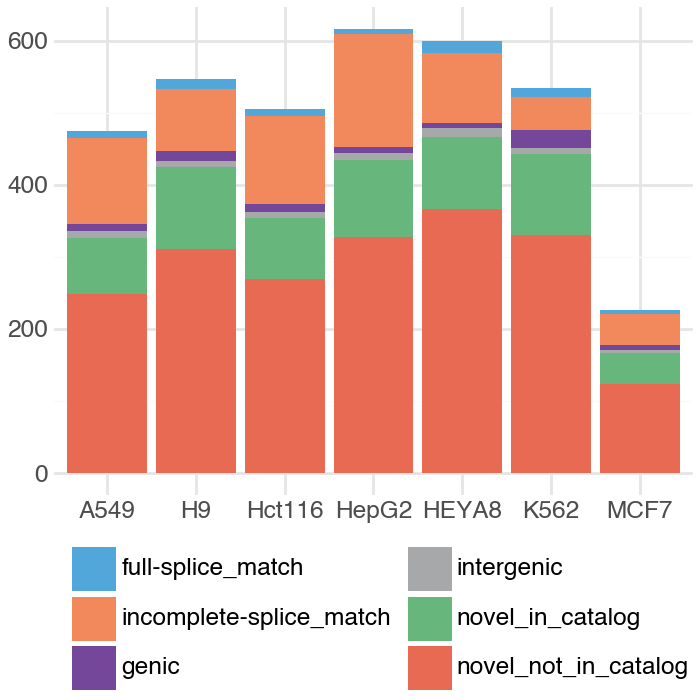

In [9]:
sqanti_labels = sqanti_labels + p9.labs(x="", fill="", y="") + p9.theme(figure_size=(
    3.5, 3.5)) + p9.theme(legend_position="bottom") + p9.guides(fill=p9.guide_legend(nrow=3))
sqanti_labels

In [10]:
sqanti_labels.save(project_path+publication_figures + "figure3/"
                   + "new_sqanti3_label_numbers_in_switching_pairs.png", dpi=600, width=3.5, height=3.5)

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3.5 x 3.5 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/new_sqanti3_label_numbers_in_switching_pairs.png


## Number of structural differences detected between switching isoforms (Figure 3g)

In [11]:
all_dtu_pairs = collect_results[(
    collect_results['pair_label'] == 'Switching isoforms')]

all_dtu_pairs.loc[:, "sample_id"] = "switching_" + \
    all_dtu_pairs.loc[:, "cell_line"]

# all_dtu_pairs_test = collect_results[(
#     collect_results['pair_label'] == 'test_ Switching isoforms')]

# all_dtu_pairs_test.loc[:, "sample_id"] = "switching_test_" + \
#     all_dtu_pairs_test.loc[:, "cell_line"]


results_to_plot = pd.concat([all_dtu_pairs])  # ,all_dtu_pairs_test])


# %%
results_to_plot.loc[:, "sample"] = results_to_plot.loc[:,
                                                       "sample_id"].str.split("_", expand=True)[1]
explode_linked_events = results_to_plot.explode("linked_events_labels")
explode_linked_events.linked_events_labels
explode_linked_events["truncated_linked_event_name"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[0]
explode_linked_events["truncated_linked_edge_label"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[1]


# remove all cases of "no_events" labels (needed to account for background pairs in which the transcripts passes are actually identical despite having different id's)
explode_linked_events = explode_linked_events[explode_linked_events["truncated_linked_edge_label"] .isin([
                                                                                                         '5prime', 'internal', '3prime'])]

/var/folders/nw/14x9j20n5dn3x3kh75dzj7l40000gp/T/ipykernel_24705/812174528.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [12]:

explode_linked_events.groupby(["cell_line", "pair_label"]).count(
).reset_index()  # to_frame(name="total_in_group")

group_by_df = explode_linked_events.groupby(
    ["cell_line", "pair_label", "truncated_linked_edge_label", "truncated_linked_event_name"]).count().reset_index()
prop_df = pd.merge(group_by_df, explode_linked_events.groupby(["cell_line", "pair_label", "truncated_linked_edge_label"]).count(
).reset_index(), on=["cell_line", "pair_label", "truncated_linked_edge_label"], how="left")
prop_df["group_proportion"] = prop_df.feature_iddRNA_x / \
    prop_df.linked_events_dict_y
prop_df

,cell_line,pair_label,truncated_linked_edge_label,truncated_linked_event_name_x,gene_id_x,feature_iddRNA_x,feature_idcDNA_x,chrdRNA_x,stranddRNA_x,starts_npdRNA_x,...,linked_events_labels_old_y,linked_events_dict_old_y,linked_events_labels_y,linked_events_dict_y,geneID_y,mean_expression.x_y,sample_id_y,sample_y,truncated_linked_event_name_y,group_proportion
0,A549,Switching isoforms,3prime,extended\nexon(3'),73,73,73,73,73,73,...,199,199,199,199,199,199,199,199,199,0.366834
1,A549,Switching isoforms,3prime,inserted\nexon,1,1,1,1,1,1,...,199,199,199,199,199,199,199,199,199,0.005025
2,A549,Switching isoforms,3prime,linked\ncombination,66,66,66,66,66,66,...,199,199,199,199,199,199,199,199,199,0.331658
3,A549,Switching isoforms,3prime,linked\ndeletion,2,2,2,2,2,2,...,199,199,199,199,199,199,199,199,199,0.010050
4,A549,Switching isoforms,3prime,linked\ninsertion,6,6,6,6,6,6,...,199,199,199,199,199,199,199,199,199,0.030151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,MCF7,Switching isoforms,internal,linked\ndeletion,4,4,4,4,4,4,...,96,96,96,96,96,96,96,96,96,0.041667
163,MCF7,Switching isoforms,internal,linked\ninsertion,2,2,2,2,2,2,...,96,96,96,96,96,96,96,96,96,0.020833
164,MCF7,Switching isoforms,internal,skipped\nexon,18,18,18,18,18,18,...,96,96,96,96,96,96,96,96,96,0.187500
165,MCF7,Switching isoforms,internal,truncated\nexon(3'),2,2,2,2,2,2,...,96,96,96,96,96,96,96,96,96,0.020833


/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/temp_events_proportions_in_switching_pairs.png


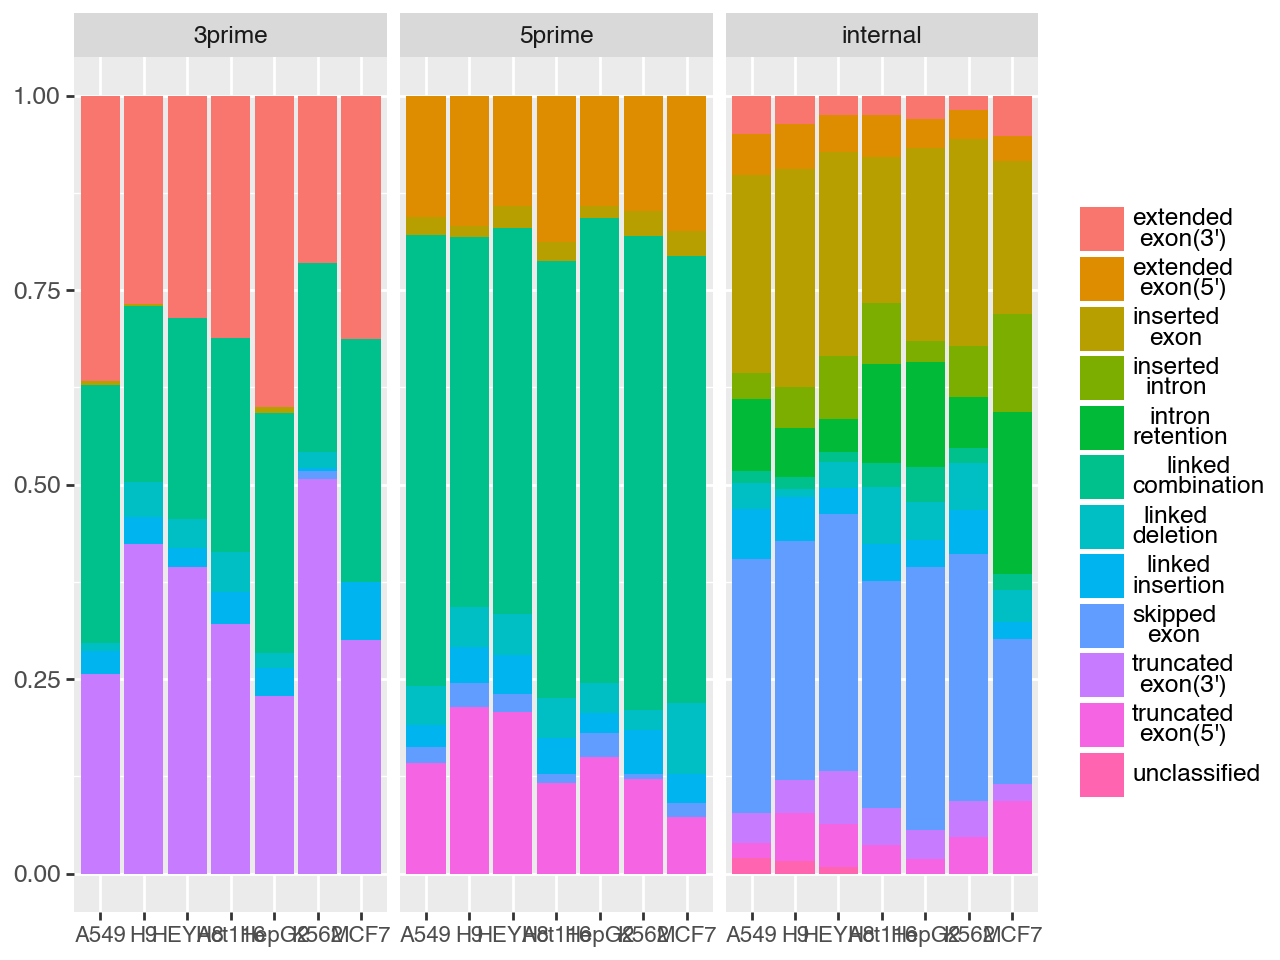

In [13]:
prop_df['show_label'] = prop_df["truncated_linked_edge_label"].apply(
    lambda x: x == '3prime')
fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="group_proportion", fill="truncated_linked_event_name_x")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                                          scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.geom_text(x=4, y=60, label="switching pairs", size=8, data=prop_df[prop_df['show_label']])
fig3g.save(project_path+publication_figures + "figure3/"
           + "temp_events_proportions_in_switching_pairs.png", dpi=600
           )
fig3g

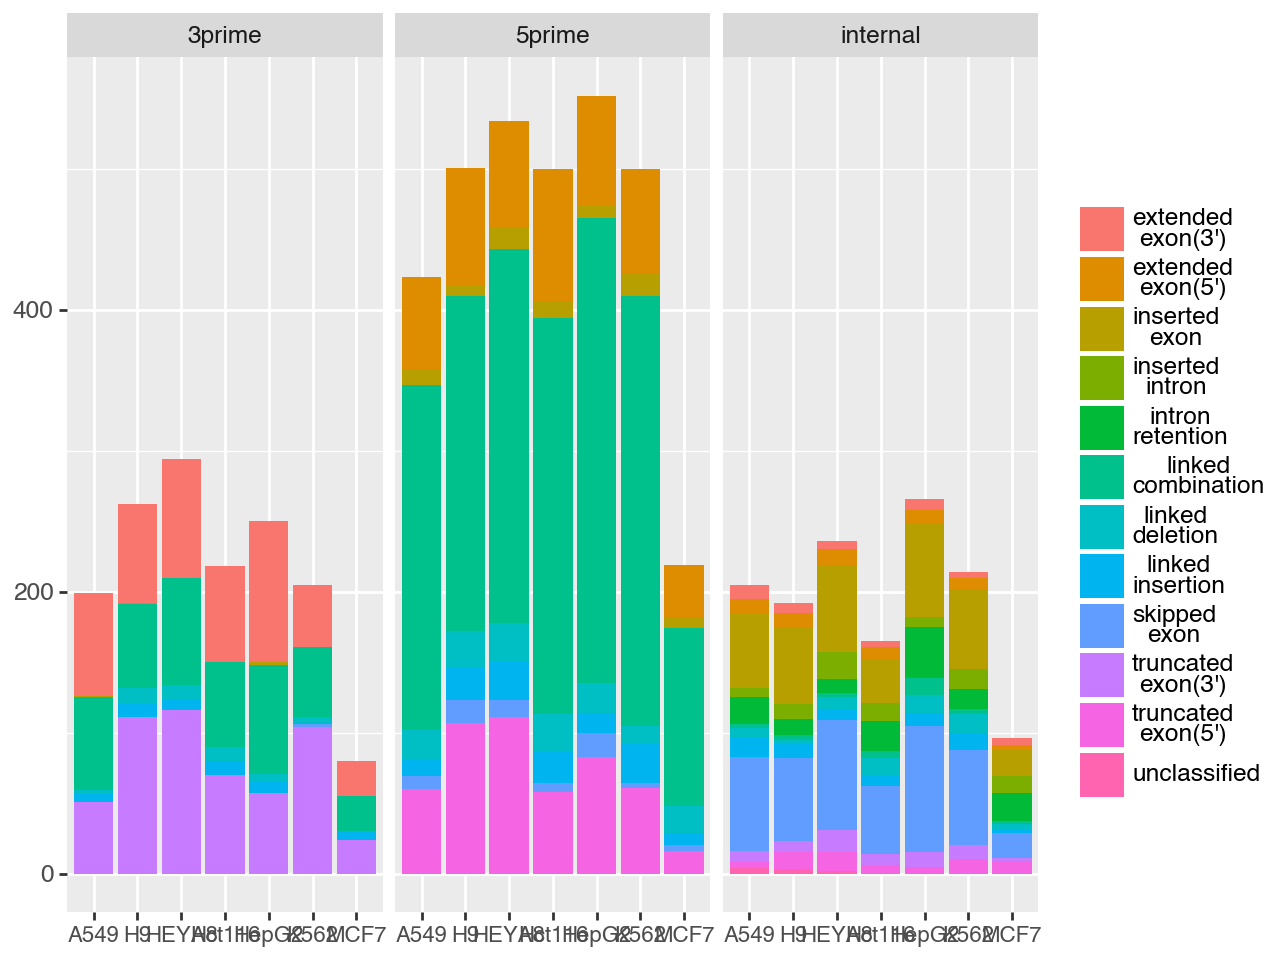

In [14]:
prop_df['show_label'] = prop_df["truncated_linked_edge_label"].apply(
    lambda x: x == '3prime')
fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="feature_iddRNA_x", fill="truncated_linked_event_name_x")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                                          scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8))
# + p9.geom_text(x=4, y=60, label="switching pairs", size=8, data=prop_df[prop_df['show_label']])
fig3g  # + p9.geom_text(x=22, y=60, label="sampled from background pairs",
#                     size=8, data=prop_df[prop_df['show_label']])

In [15]:
from transparent._config import DIFF_COLORS, DIFF_COLORS_HEX, ORDER_EVENTS

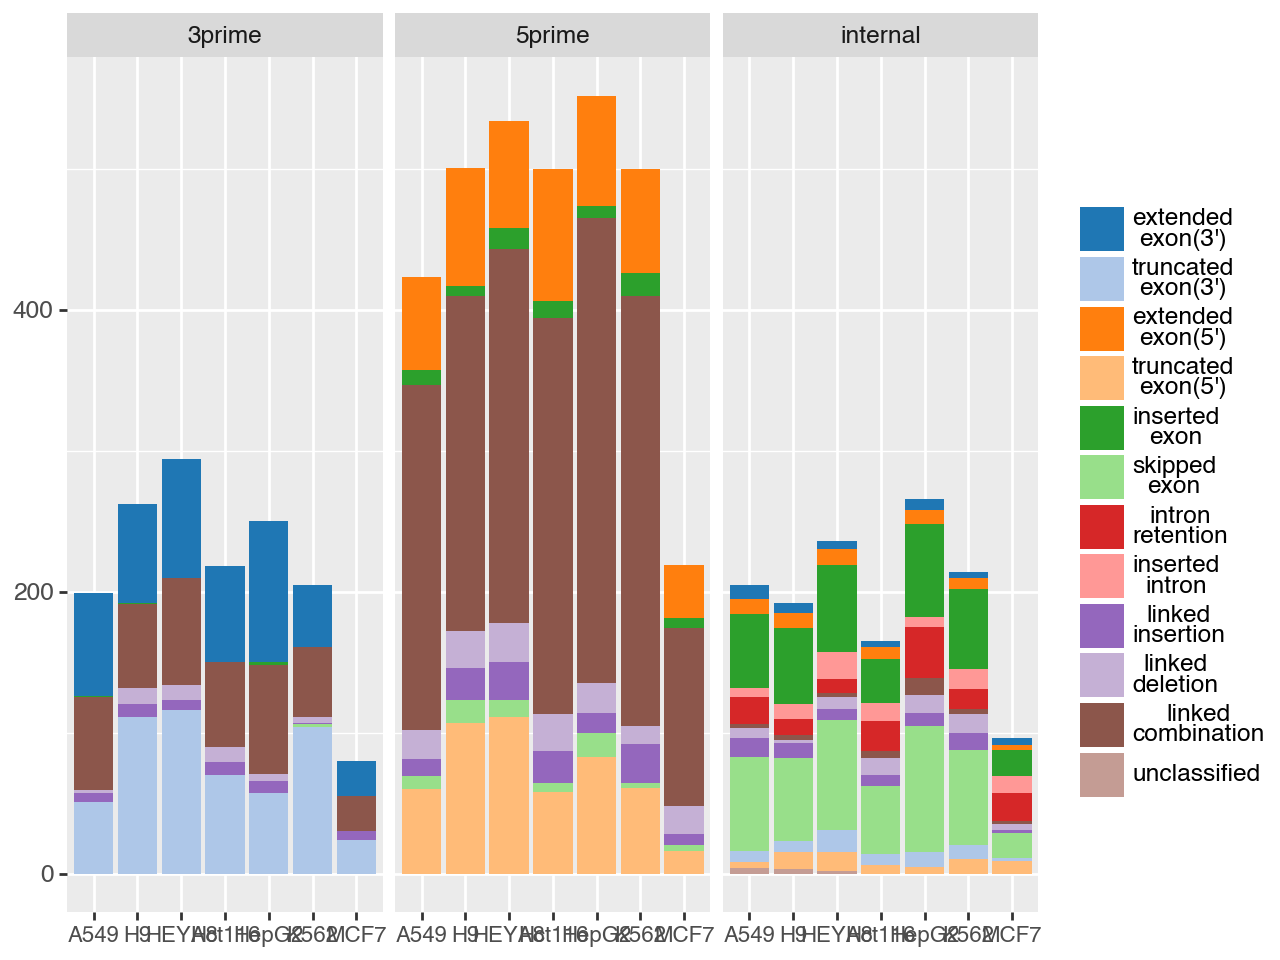

In [16]:
fig3g + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

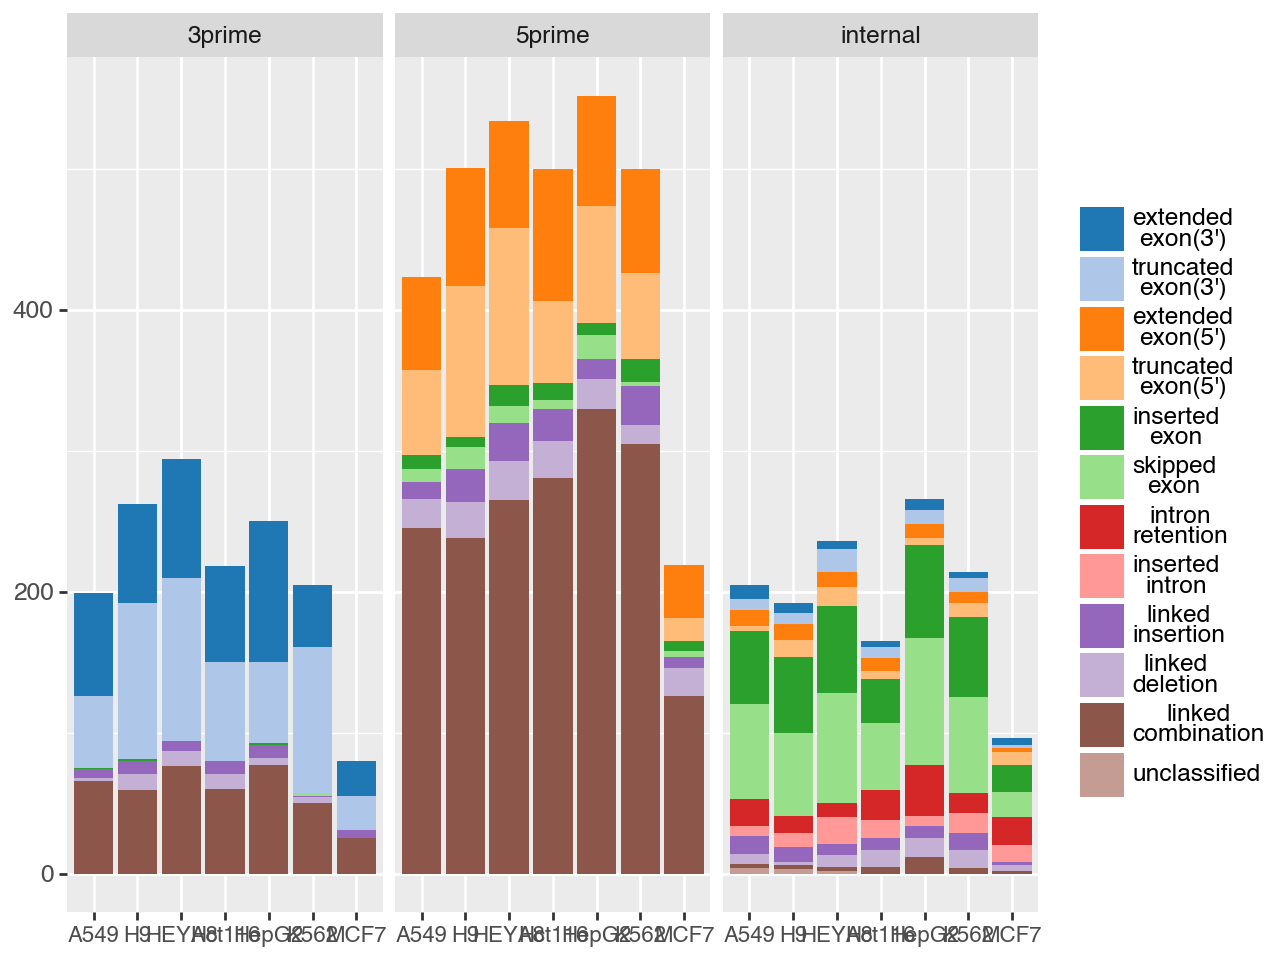

In [17]:
prop_df['ordered_events'] = pd.Categorical(prop_df["truncated_linked_event_name_x"],
                                           categories=ORDER_EVENTS, ordered=True)


fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="feature_iddRNA_x", fill="ordered_events")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                           scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

fig3g

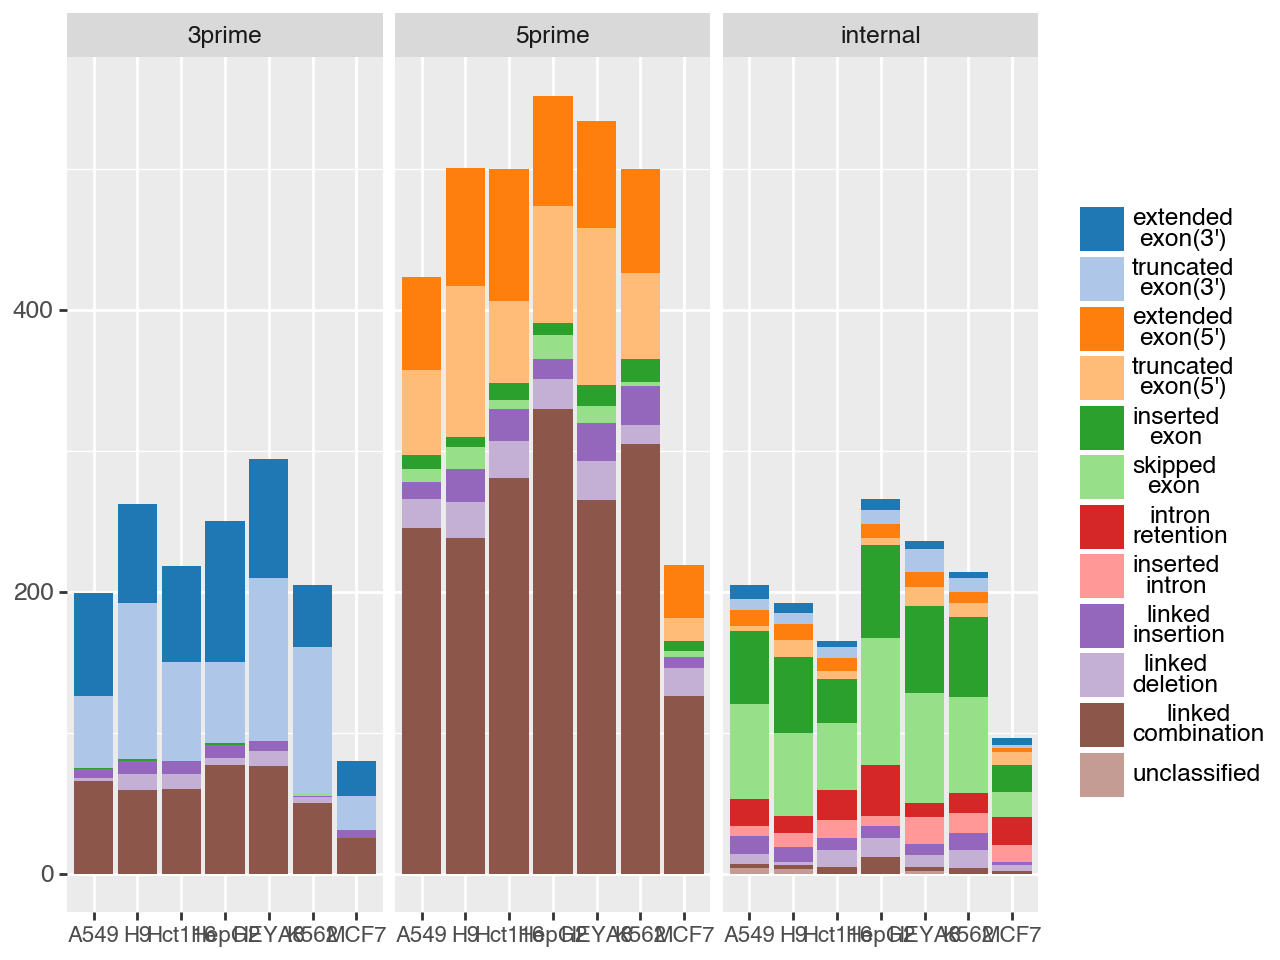

In [18]:

# 1. Sort the unique values alphabetically
sorted_categories = ["A549",  "H9", "Hct116",
                     "HepG2", "HEYA8",  "K562", "MCF7"]

# 2. Assign the sorted categorical dtype back to the column
prop_df['sorted_cell_line'] = pd.Categorical(
    prop_df['cell_line'],
    categories=sorted_categories,
    ordered=True
)
fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="sorted_cell_line", y="feature_iddRNA_x", fill="ordered_events")) + p9.geom_bar(stat="identity") + p9.facet_grid(
    cols="truncated_linked_edge_label",
    scales="free") + p9.labs(x="",
                             y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

fig3g

In [19]:
fig_size = [12, 4]
fig3g.save(project_path+publication_figures + "figure3/"
           + "event_numbers_in_switching_pairs.png",  width=fig_size[0], height=fig_size[1], dpi=600)
plt.style.use('ggplot')

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/event_numbers_in_switching_pairs.png


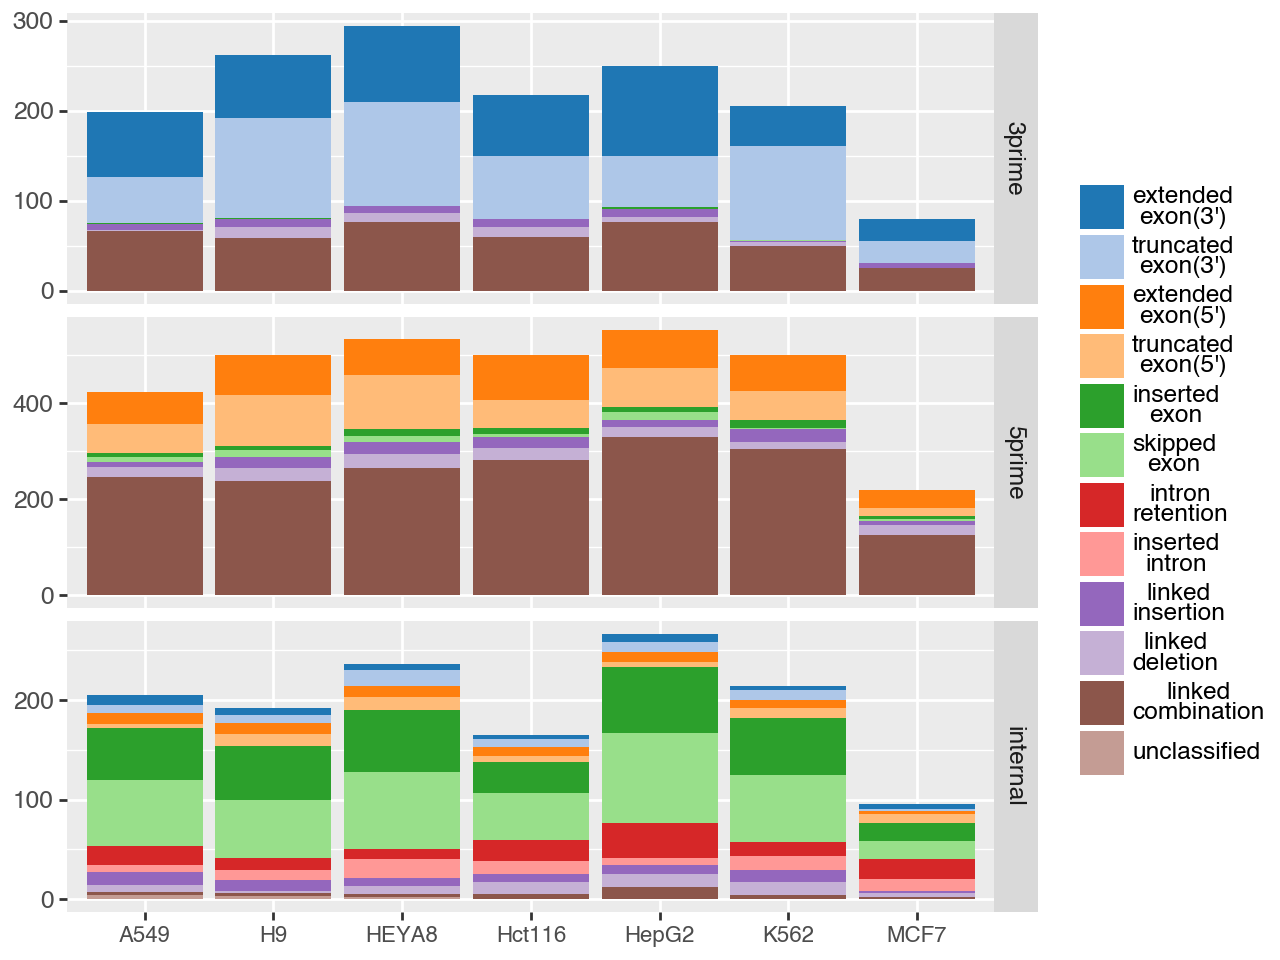

In [20]:
fig3g_vertical = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="feature_iddRNA_x", fill="ordered_events")) + p9.geom_bar(stat="identity") + p9.facet_grid(
    rows="truncated_linked_edge_label",                                    scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

fig3g_vertical

In [21]:
width_inches = 5
height_inches = 12
dpi = 900

In [22]:
fig3g_vertical = fig3g_vertical + \
    p9.theme(figure_size=(width_inches, height_inches))

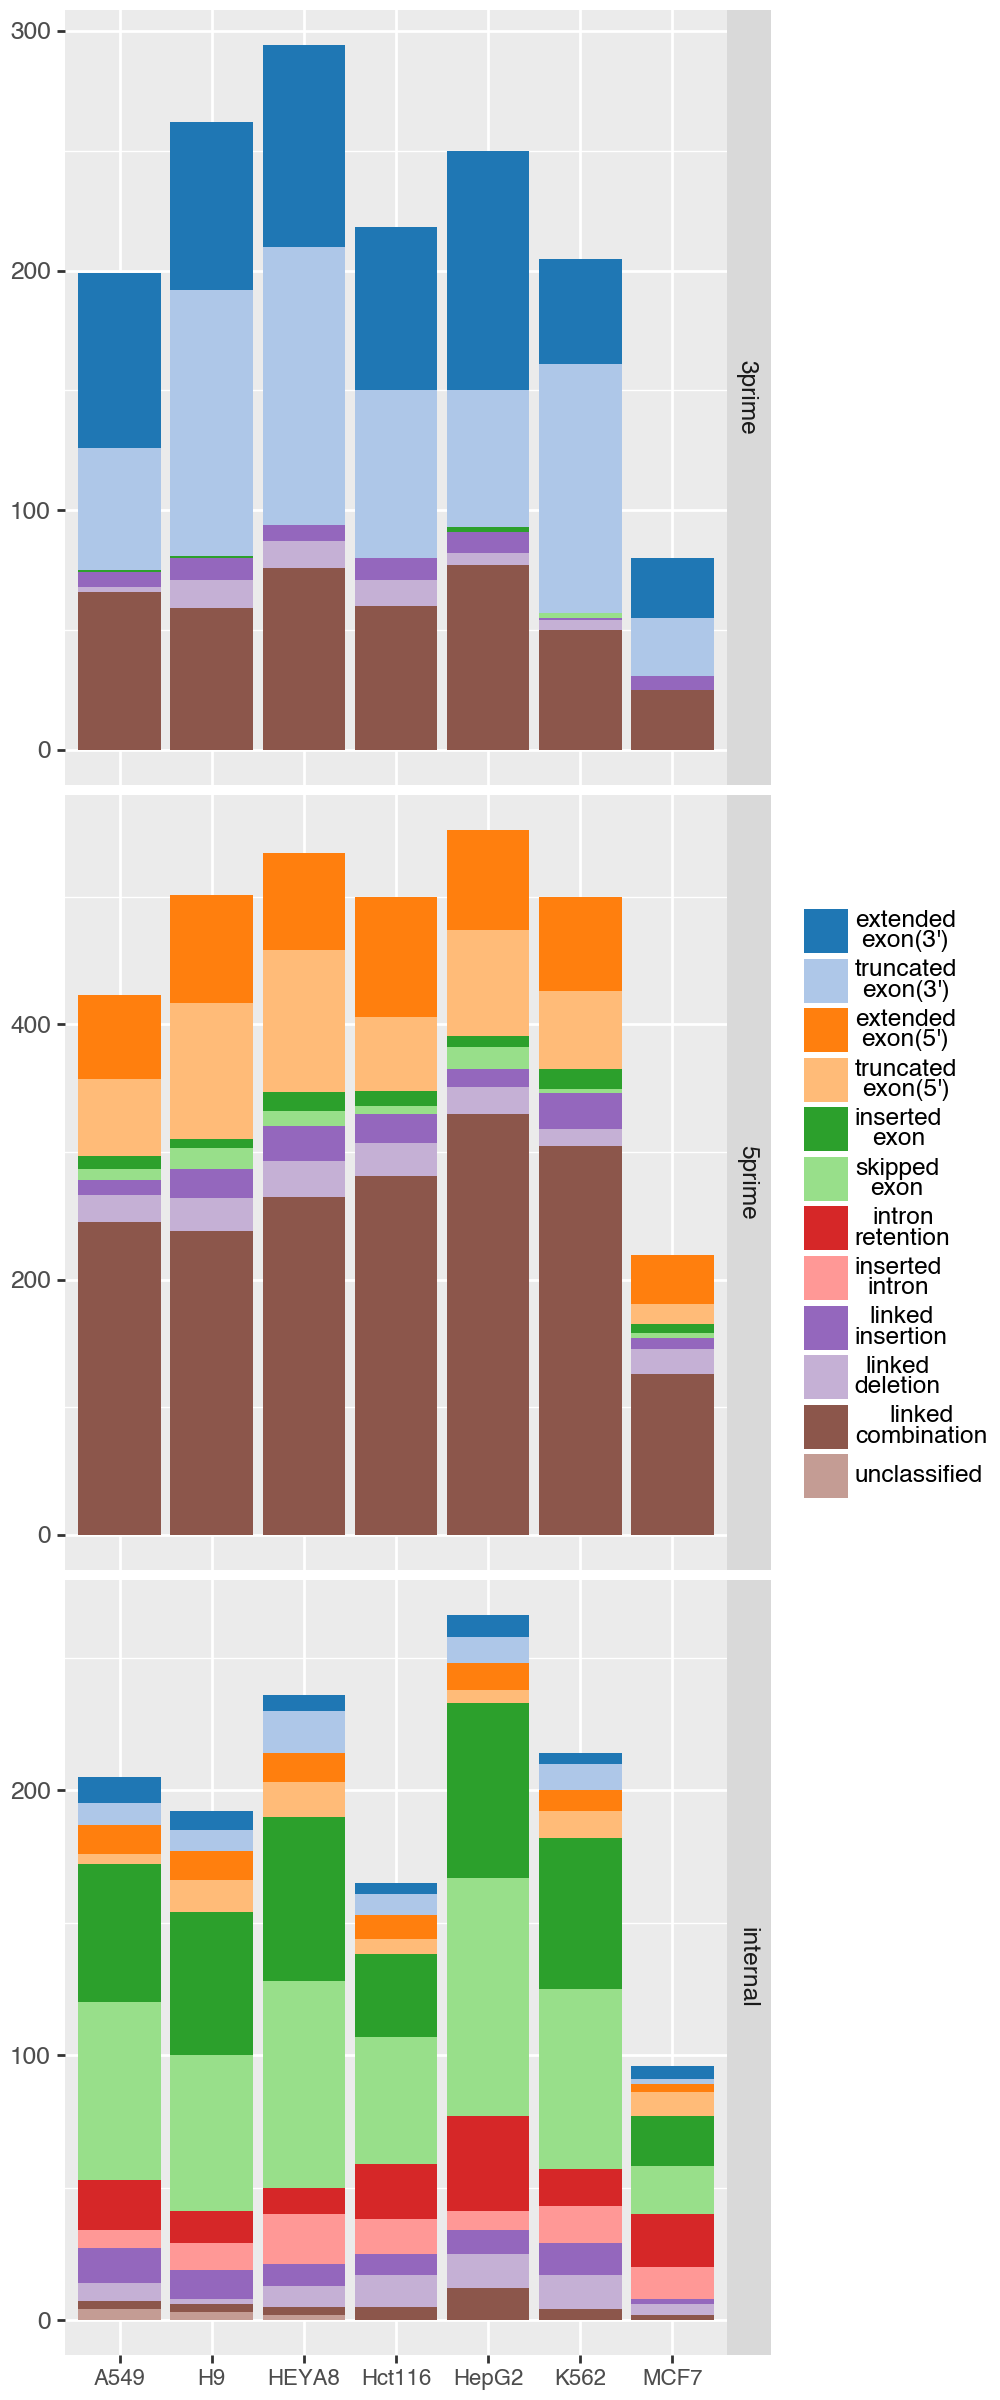

In [23]:
fig3g_vertical

In [24]:
fig3g_vertical.save(project_path+publication_figures + "figure3/"
                    + "temp_event_numbers_in_switching_pairs_vertical.pdf", width=width_inches, height=height_inches, dpi=dpi)

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5 x 12 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/temp_event_numbers_in_switching_pairs_vertical.pdf


## Distribution of structural differences varies between isoform switching and background pairs

In [25]:
collect_results_to_review = collect_results.copy(deep=True)
explode_linked_events = collect_results_to_review.explode(
    "linked_events_labels")
explode_linked_events.linked_events_labels
explode_linked_events["truncated_linked_event_name"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[0]
explode_linked_events["truncated_linked_edge_label"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[1]


explode_linked_events["truncated_linked_edge_label"].value_counts(dropna=False)
explode_linked_events = explode_linked_events[explode_linked_events["truncated_linked_edge_label"] .isin([
                                                                                                         '5prime', 'internal', '3prime'])]
explode_linked_events.groupby(["cell_line", "pair_label"]).count(
).reset_index()  # to_frame(name="total_in_group")

group_by_df = explode_linked_events.groupby(
    ["cell_line", "pair_label", "truncated_linked_edge_label", "truncated_linked_event_name"]).count().reset_index()
prop_df = pd.merge(group_by_df, explode_linked_events.groupby(["cell_line", "pair_label", "truncated_linked_edge_label"]).count(
).reset_index(), on=["cell_line", "pair_label", "truncated_linked_edge_label"], how="left")
prop_df["group_proportion"] = prop_df.gene_id_x / prop_df.gene_id_y
prop_df

,cell_line,pair_label,truncated_linked_edge_label,truncated_linked_event_name_x,gene_id_x,feature_iddRNA_x,feature_idcDNA_x,chrdRNA_x,stranddRNA_x,starts_npdRNA_x,...,lengths_y,links_dict_y,linked_events_labels_old_y,linked_events_dict_old_y,linked_events_labels_y,linked_events_dict_y,geneID_y,mean_expression.x_y,truncated_linked_event_name_y,group_proportion
0,A549,Background isoforms,3prime,extended\nexon(3'),194,194,194,194,194,194,...,1404,1404,1404,1404,1404,1404,1404,1404,1404,0.138177
1,A549,Background isoforms,3prime,linked\ncombination,444,444,444,444,444,444,...,1404,1404,1404,1404,1404,1404,1404,1404,1404,0.316239
2,A549,Background isoforms,3prime,linked\ndeletion,44,44,44,44,44,44,...,1404,1404,1404,1404,1404,1404,1404,1404,1404,0.031339
3,A549,Background isoforms,3prime,linked\ninsertion,6,6,6,6,6,6,...,1404,1404,1404,1404,1404,1404,1404,1404,1404,0.004274
4,A549,Background isoforms,3prime,skipped\nexon,1,1,1,1,1,1,...,1404,1404,1404,1404,1404,1404,1404,1404,1404,0.000712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,MCF7,Switching isoforms,internal,linked\ndeletion,4,4,4,4,4,4,...,96,96,96,96,96,96,96,96,96,0.041667
336,MCF7,Switching isoforms,internal,linked\ninsertion,2,2,2,2,2,2,...,96,96,96,96,96,96,96,96,96,0.020833
337,MCF7,Switching isoforms,internal,skipped\nexon,18,18,18,18,18,18,...,96,96,96,96,96,96,96,96,96,0.187500
338,MCF7,Switching isoforms,internal,truncated\nexon(3'),2,2,2,2,2,2,...,96,96,96,96,96,96,96,96,96,0.020833


### Direct comparison

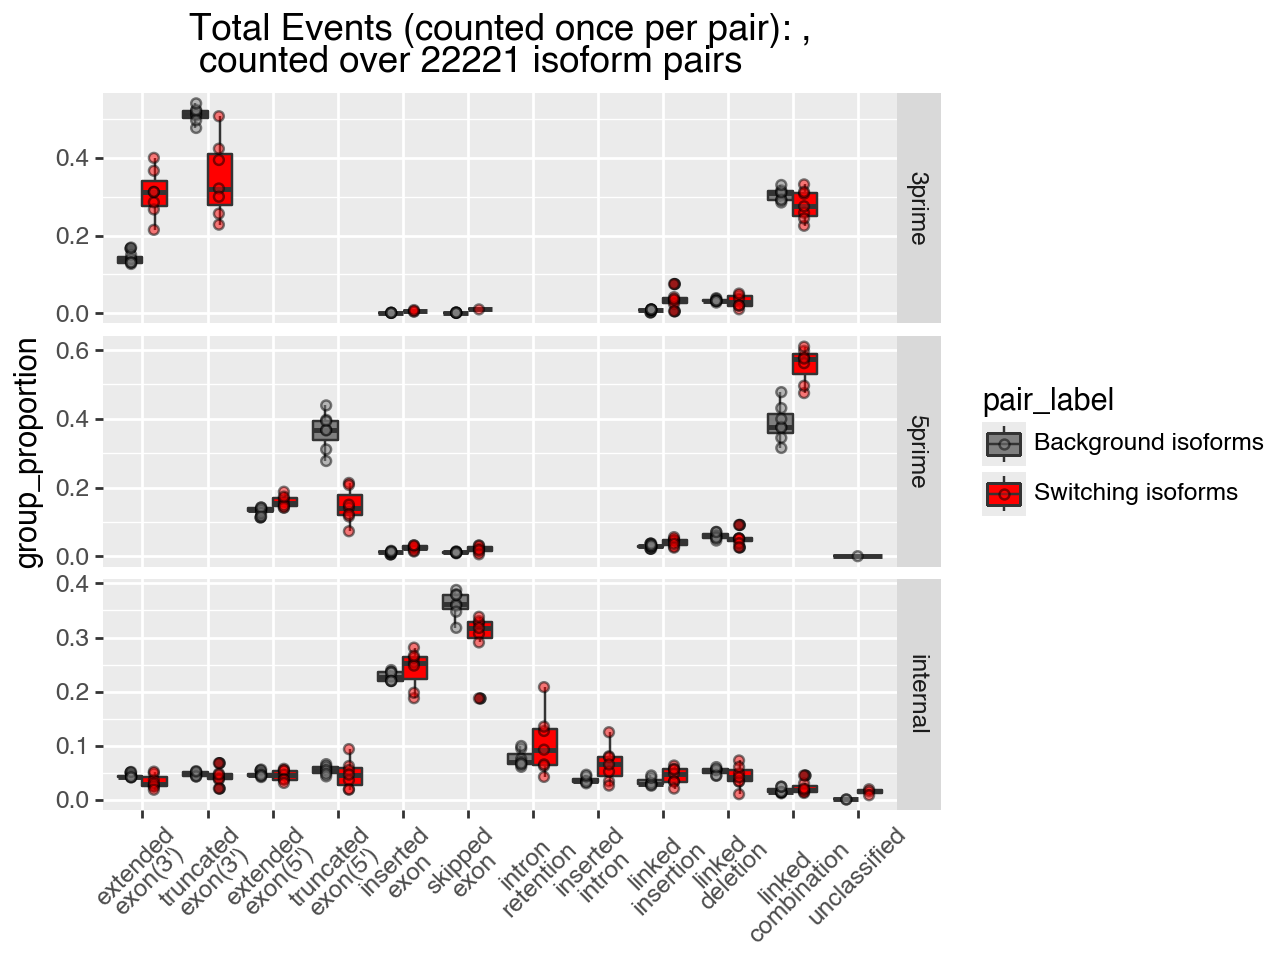

In [26]:
# Create factor with custom order
event_names_order = ['linkedCombination', 'linkeddeletion', 'linkedinsertion', "extended\nexon(5')", "truncated\nexon(5')",
                     'inserted\nexon', 'inserted\nintron', 'intron\nretention',
                     'skipped\nexon', "extended\nexon(3')", "truncated\nexon(3')"]
prop_df['event_name_ordered'] = pd.Categorical(
    prop_df['truncated_linked_event_name_x'], categories=ORDER_EVENTS)


p9.ggplot(data=prop_df, mapping=p9.aes(x="event_name_ordered", y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + p9.theme(axis_text_x=p9.element_text(angle=45)) + \
    p9.labs(title="Total Events (counted once per pair): " +
            ",\n counted over " +
            str(collect_results.shape[0]) + " isoform pairs", x="") + p9.scale_fill_manual(["grey", "red", "orange"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(width=0.7)) + p9.facet_grid(rows="truncated_linked_edge_label", scales="free")

But recall mean expression bias in DTU gene

/var/folders/nw/14x9j20n5dn3x3kh75dzj7l40000gp/T/ipykernel_24705/1618377587.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


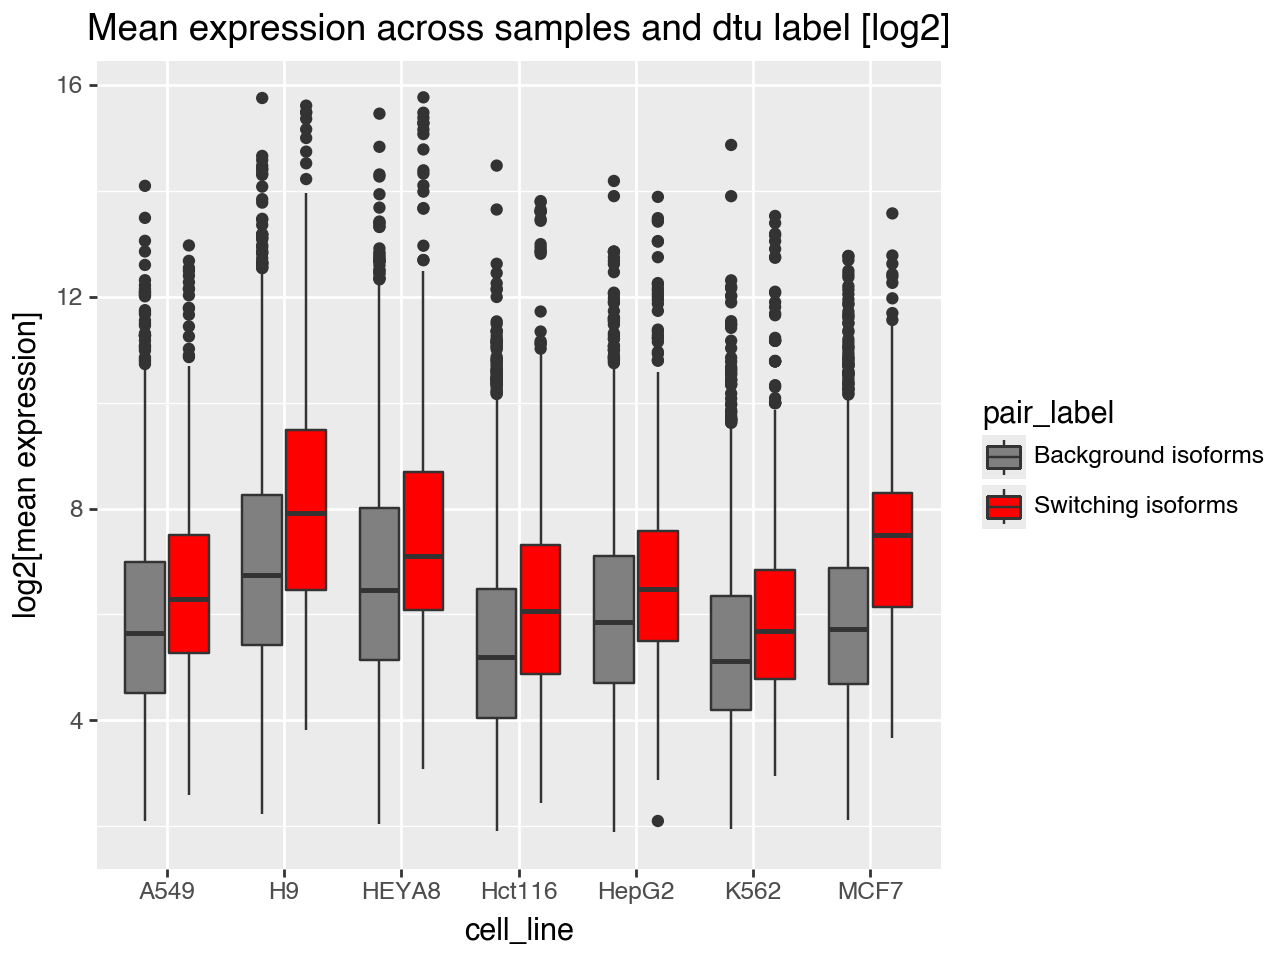

In [27]:
all_background_pairs = collect_results[(
    collect_results['pair_label'] == 'Background isoforms')]

all_background_pairs.loc[:, "sample_id"] = "background_" + \
    all_background_pairs.loc[:, "cell_line"]


results_to_plot = pd.concat([all_dtu_pairs, all_background_pairs])


dtu_label_color = {1: 'red', 0: 'gray'}

p9.ggplot(results_to_plot, p9.aes(x="cell_line", y="mean_expression", color="pair_label")) + p9.geom_boxplot() + \
    p9.labs(title="Mean expression across samples", x="") + p9.scale_color_manual(
        values=dtu_label_color)  # ,  labels = ["non sig","dtu"], name='')

dtu_label_color = {1: 'red', 0: 'gray',
                   'Switching isoforms': 'red', 'Background isoforms': 'gray'}

results_to_plot["log2_mean_expr"] = np.log2(
    results_to_plot["mean_expression.x"])

p9.ggplot(results_to_plot, p9.aes(x="cell_line", y="log2_mean_expr", fill="pair_label")) + p9.geom_boxplot() + \
    p9.labs(title="Mean expression across samples and dtu label [log2]", y="log2[mean expression]") + p9.scale_fill_manual(
        values=dtu_label_color)  # ,  labels = ['Background isoforms', 'Switching isoforms'], name='')

### Sample sets of background genes to match meanExp distribution

In [28]:
from transparent._utilities import get_bin_stats, sample_groups_varying_n

In [29]:
upper_lim = np.log2(5000)

set_bins = np.arange(0, upper_lim+25, 1)


upper_lim = np.log2(5000)
lower_lim = np.log2(0+1)
n_bins = 50
collect_results["binned_expression"] = np.log2(
    collect_results.loc[:, "mean_expression.x"])
collect_results['mean_expression'] = np.log2(
    collect_results.loc[:, "mean_expression.x"])


# complete these cases to capture outliers

collect_results["binned_expression"] = np.where(
    collect_results['mean_expression'] < lower_lim, lower_lim, collect_results['mean_expression'])
collect_results["binned_expression"] = np.where(
    collect_results['mean_expression'] > upper_lim, upper_lim, collect_results['mean_expression'])

In [30]:
# Sample from background pairs to match dtu pairs mean expression distribution
all_background_pairs = collect_results[collect_results['pair_label']
                                       == 'Background isoforms']
all_dtu_pairs = collect_results[collect_results['pair_label']
                                == 'Switching isoforms']

dtu_data, weights_data = get_bin_stats(
    all_dtu_pairs, "binned_expression", n_bins=set_bins)
dtu_weights_dict = dict(zip(weights_data['left'], weights_data["proportions"]))

dtu_data = pd.merge(dtu_data, weights_data, left_on="bins",
                    right_on="bin", how="inner")


background_data, weights_data = get_bin_stats(
    all_background_pairs, "binned_expression", n_bins=set_bins)
background_weights_dict = dict(
    zip(weights_data['left'], weights_data["proportions"]))

background_data = pd.merge(
    background_data, weights_data, left_on="bins", right_on="bin", how="inner")


collect_samples = pd.DataFrame()
for i in np.arange(5):
    sampled_df = sample_groups_varying_n(
        df=background_data, group_col="left", overall_samples=100, weights_dict=dtu_weights_dict)
    sampled_df.loc[:, "sample_id"] = "sample_" + str(i)
    collect_samples = pd.concat([collect_samples, sampled_df])

    sampled_df.mean_expression.hist(bins=100)
    # plt.xlim(0,2000)

/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_utilities.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_utilities.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/scales/scale_alpha.py:71: PlotnineWarning: Using alpha for a discrete variable is not advised.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it


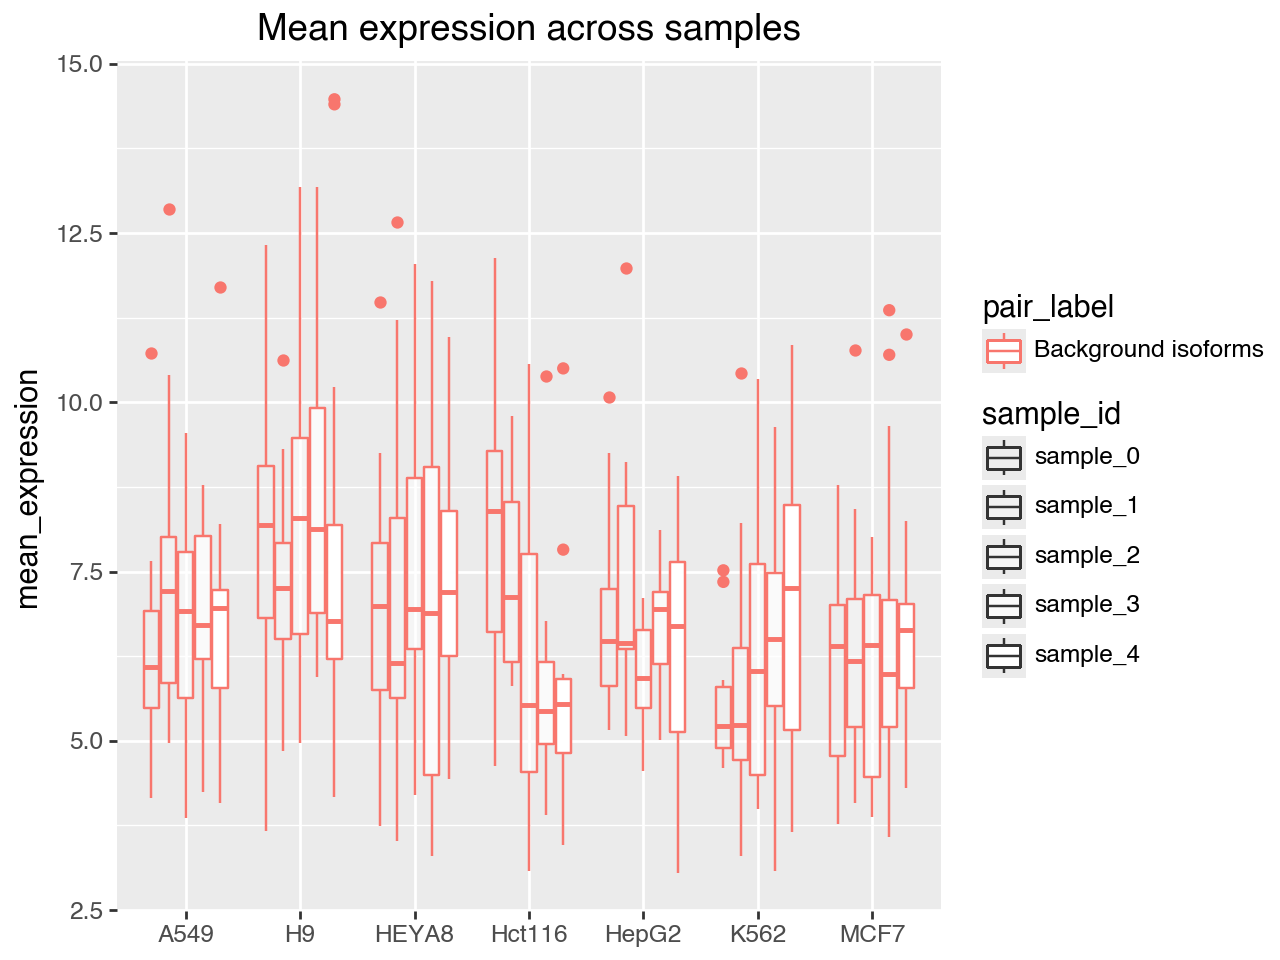

In [31]:
dtu_label_color = {1: 'red', 0: 'gray'}

# results_to_plot["log2_mean_expr"] = np.log2(results_to_plot["mean_expression.x"])

p9.ggplot(collect_samples, p9.aes(x="cell_line", y="mean_expression", color="pair_label", alpha="sample_id")) + p9.geom_boxplot() + \
    p9.labs(title="Mean expression across samples", x="") + \
    p9.scale_fill_manual(values=dtu_label_color,  labels=[
                         "non sig", "dtu"], name='')

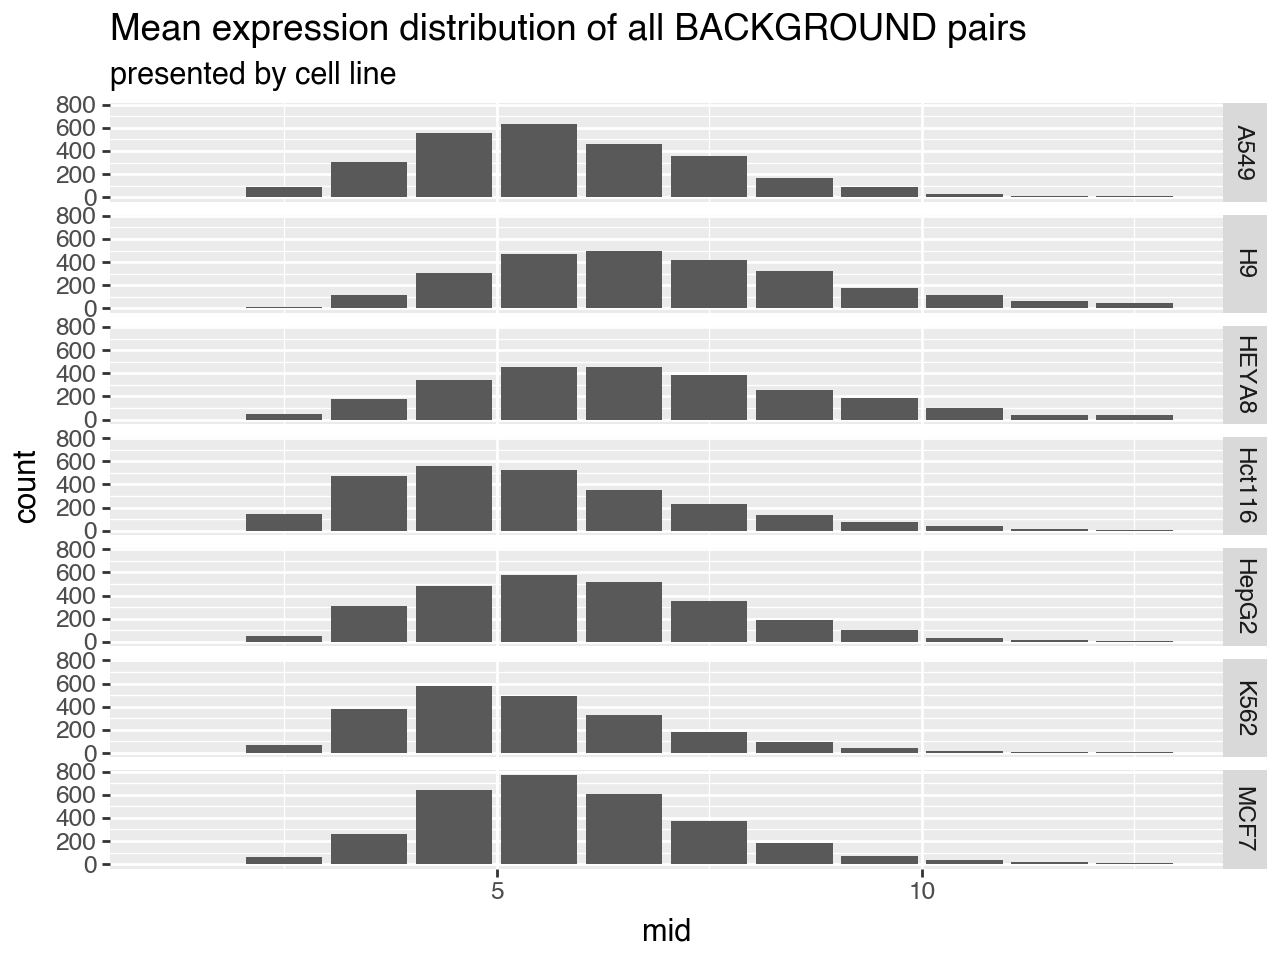

In [32]:
# | layout-ncol: 2
# | fig-cap:
# |   - "First Plot Caption"
# |   - "Second Plot Caption"

p9.ggplot(dtu_data, p9.aes(x="mid")) + p9.geom_bar() + p9.facet_grid(rows="cell_line") + p9.theme(axis_text_x=p9.element_text(angle=45)
                                                                                                  ) + p9.labs(title="Mean expression distribution of all DTU pairs", subtitle="presented by cell line")

p9.ggplot(background_data, p9.aes(x="mid")) + p9.geom_bar() + p9.facet_grid(rows="cell_line") + \
    p9.labs(title="Mean expression distribution of all BACKGROUND pairs",
            subtitle="presented by cell line")

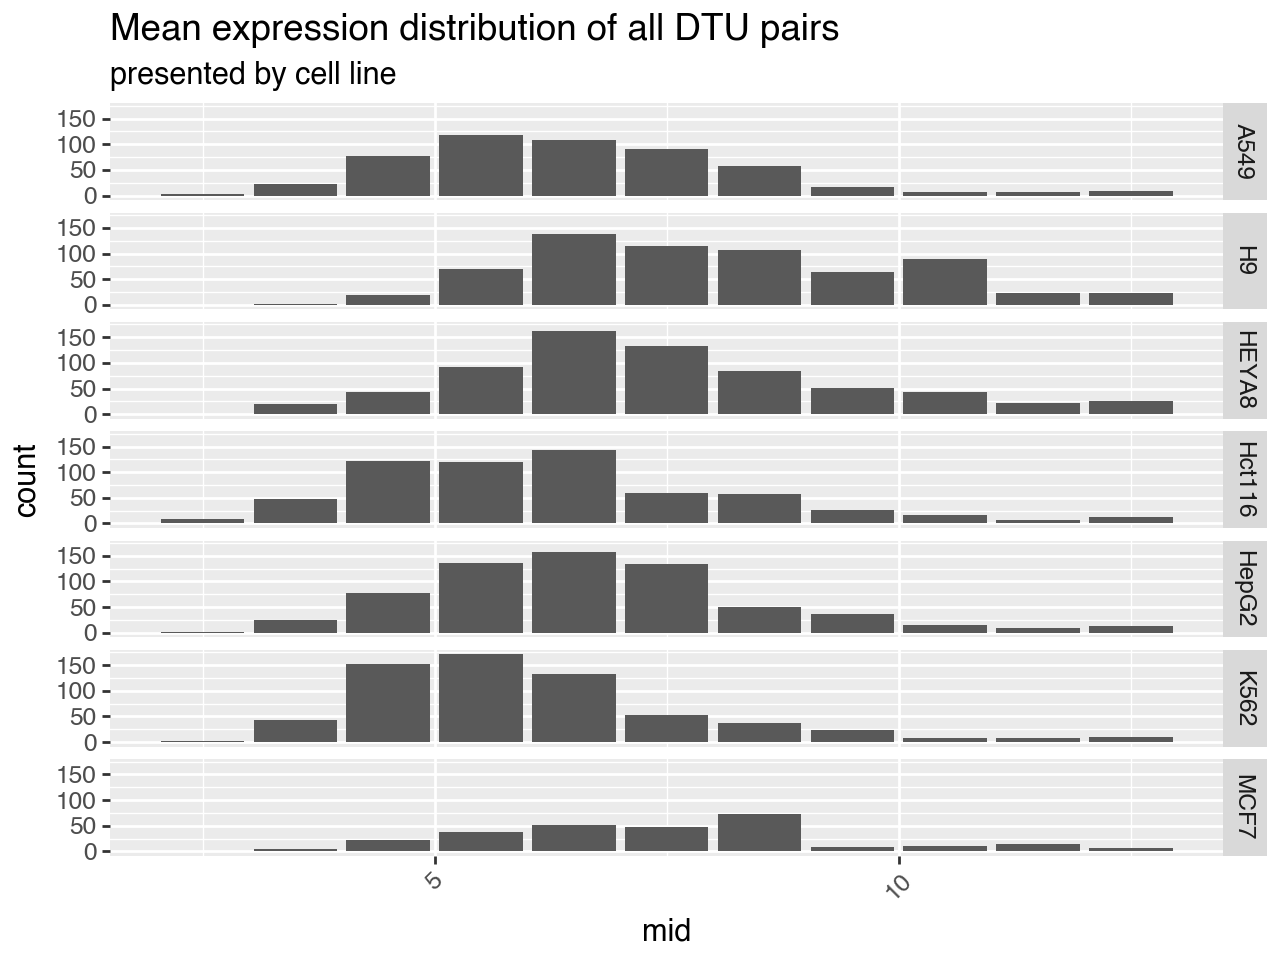

In [33]:
p9.ggplot(dtu_data, p9.aes(x="mid")) + p9.geom_bar() + p9.facet_grid(rows="cell_line") + p9.theme(axis_text_x=p9.element_text(angle=45)
                                                                                                  ) + p9.labs(title="Mean expression distribution of all DTU pairs", subtitle="presented by cell line")

In [34]:
# Sample from background pairs to match dtu pairs mean expression distribution
collect_samples = pd.DataFrame()
for cell_line in ["A549", "H9", "MCF7", "HEYA8", "HepG2", "K562", "Hct116"]:
    all_background_pairs = collect_results[(collect_results['pair_label'] == 'Background isoforms') & (
        collect_results['cell_line'] == cell_line)]
    all_dtu_pairs = collect_results[(collect_results['pair_label'] == 'Switching isoforms') & (
        collect_results['cell_line'] == cell_line)]

    dtu_data, weights_data = get_bin_stats(
        all_dtu_pairs, "binned_expression", n_bins=set_bins)
    dtu_weights_dict = dict(
        zip(weights_data['left'], weights_data["proportions"]))

    dtu_data = pd.merge(dtu_data, weights_data,
                        left_on="bins", right_on="bin", how="inner")

    background_data, weights_data = get_bin_stats(
        all_background_pairs, "binned_expression", n_bins=set_bins)
    background_weights_dict = dict(
        zip(weights_data['left'], weights_data["proportions"]))

    background_data = pd.merge(
        background_data, weights_data, left_on="bins", right_on="bin", how="inner")

    # collect_samples = pd.DataFrame()
    for i in np.arange(5):
        sampled_df = sample_groups_varying_n(
            df=background_data, group_col="left", overall_samples=100, weights_dict=dtu_weights_dict)
        sampled_df.loc[:, "sample_id"] = "sample_" + str(i) + "_"+cell_line
        collect_samples = pd.concat([collect_samples, sampled_df])

        sampled_df.mean_expression.hist(bins=100)
        plt.xlim(0, 2000)

/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_utilities.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_utilities.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_utilities.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

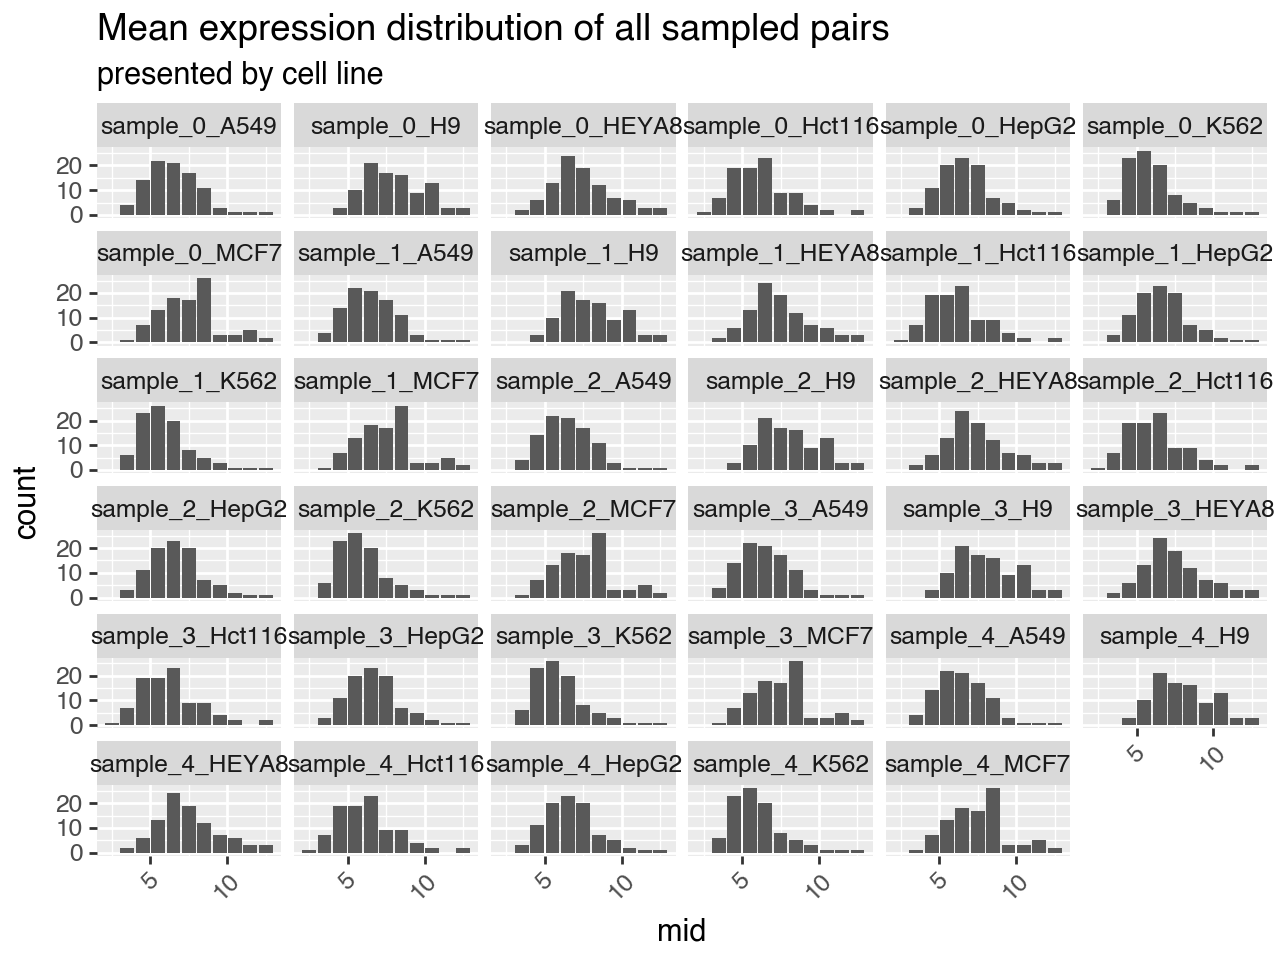

In [35]:
p9.ggplot(collect_samples, p9.aes(x="mid")) + p9.geom_bar() + p9.facet_wrap("sample_id") + p9.theme(axis_text_x=p9.element_text(angle=45)
                                                                                                    ) + p9.labs(title="Mean expression distribution of all sampled pairs", subtitle="presented by cell line")

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/scales/scale_alpha.py:71: PlotnineWarning: Using alpha for a discrete variable is not advised.


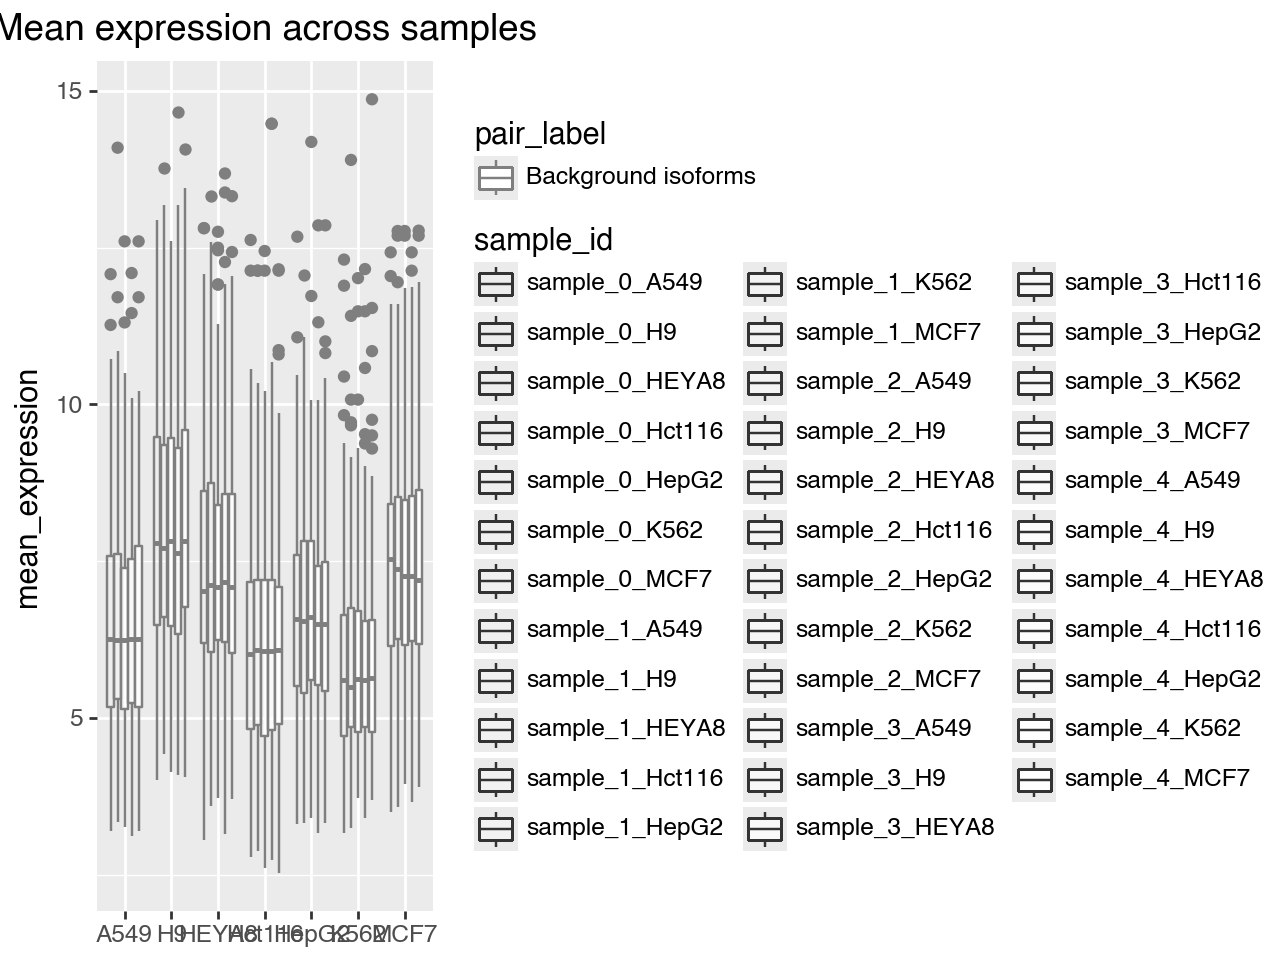

In [36]:
# results_to_plot["log2_mean_expr"] = np.log2(results_to_plot["mean_expression.x"])

p9.ggplot(collect_samples, p9.aes(x="cell_line", y="mean_expression", color="pair_label", alpha="sample_id")) + p9.geom_boxplot() + \
    p9.labs(title="Mean expression across samples", x="") + p9.scale_color_manual(
        values=dtu_label_color)  # ,  labels = ["non sig","dtu"], name='')

In [37]:
all_dtu_pairs = collect_results[(
    collect_results['pair_label'] == 'Switching isoforms')]

all_dtu_pairs["sample_id"] = "sample_00_" + all_dtu_pairs["cell_line"]
results_to_plot = pd.concat([collect_samples, all_dtu_pairs])
results_to_plot.loc[:, "sample"] = results_to_plot.loc[:,
                                                       "sample_id"].str.split("_", expand=True)[1]

/var/folders/nw/14x9j20n5dn3x3kh75dzj7l40000gp/T/ipykernel_24705/2801482770.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/scales/scale_alpha.py:71: PlotnineWarning: Using alpha for a discrete variable is not advised.


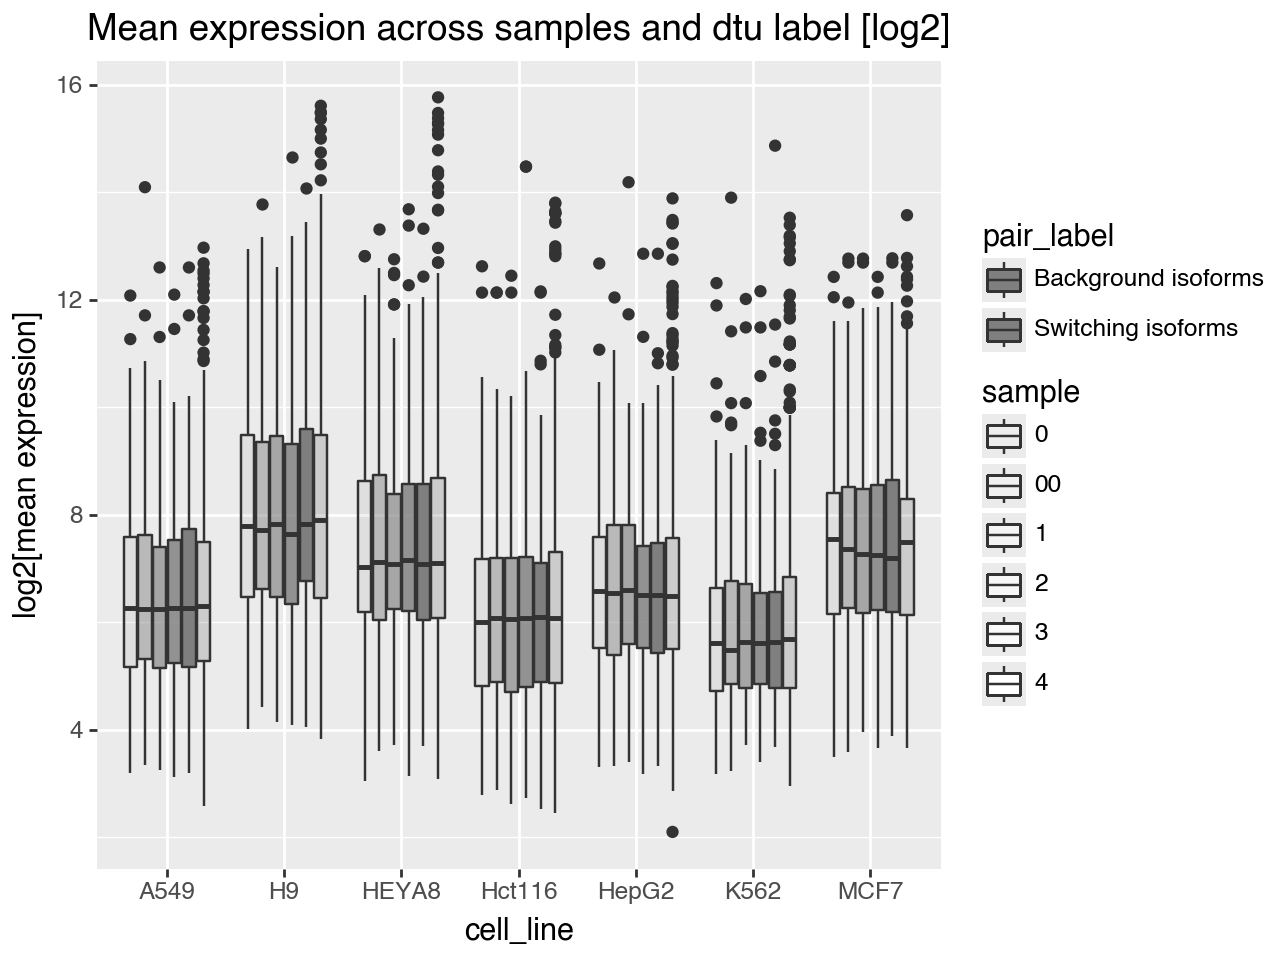

In [38]:
# collect_results


p9.ggplot(results_to_plot, p9.aes(x="cell_line", y="mean_expression", fill="pair_label", alpha="sample")) + p9.geom_boxplot() + \
    p9.labs(title="Mean expression across samples and dtu label [log2]", y="log2[mean expression]") + p9.scale_fill_manual(
        values=dtu_label_color)  # ,  labels = ['Switching isoforms',
# 'Background isoforms'], name='')

In [39]:
explode_linked_events = results_to_plot.explode("linked_events_labels")


explode_linked_events.linked_events_labels
explode_linked_events["truncated_linked_event_name"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[0]
explode_linked_events["truncated_linked_edge_label"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[1]
explode_linked_events["truncated_linked_edge_label"].value_counts(dropna=False)

truncated_linked_edge_label
5prime      5697
3prime      3275
internal    3146
events       367
Name: count, dtype: int64

In [40]:
explode_linked_events["truncated_linked_event_name"].value_counts(dropna=False)

truncated_linked_event_name
linked\ncombination    3680
truncated\nexon(3')    1666
truncated\nexon(5')    1633
skipped\nexon          1182
extended\nexon(5')      942
inserted\nexon          846
extended\nexon(3')      824
linked\ndeletion        558
no                      367
linked\ninsertion       352
intron\nretention       282
inserted\nintron        144
unclassified              9
Name: count, dtype: int64

In [41]:
explode_linked_events = explode_linked_events[explode_linked_events["truncated_linked_edge_label"] .isin([
    '5prime', 'internal', '3prime'])]

In [42]:
explode_linked_events.groupby(["sample_id", "pair_label"]).count(
).reset_index()  # to_frame(name="total_in_group")

group_by_df = explode_linked_events.groupby(
    ["sample_id", "pair_label", "truncated_linked_edge_label", "truncated_linked_event_name"]).count().reset_index()
prop_df = pd.merge(group_by_df, explode_linked_events.groupby(["sample_id", "pair_label", "truncated_linked_edge_label"]).count(
).reset_index(), on=["sample_id", "pair_label", "truncated_linked_edge_label"], how="left")
prop_df["group_proportion"] = prop_df.gene_id_x / prop_df.geneID_y
# prop_df

### Fractions of structural diffs. in switching and sampled background pairs (Figure 3i)

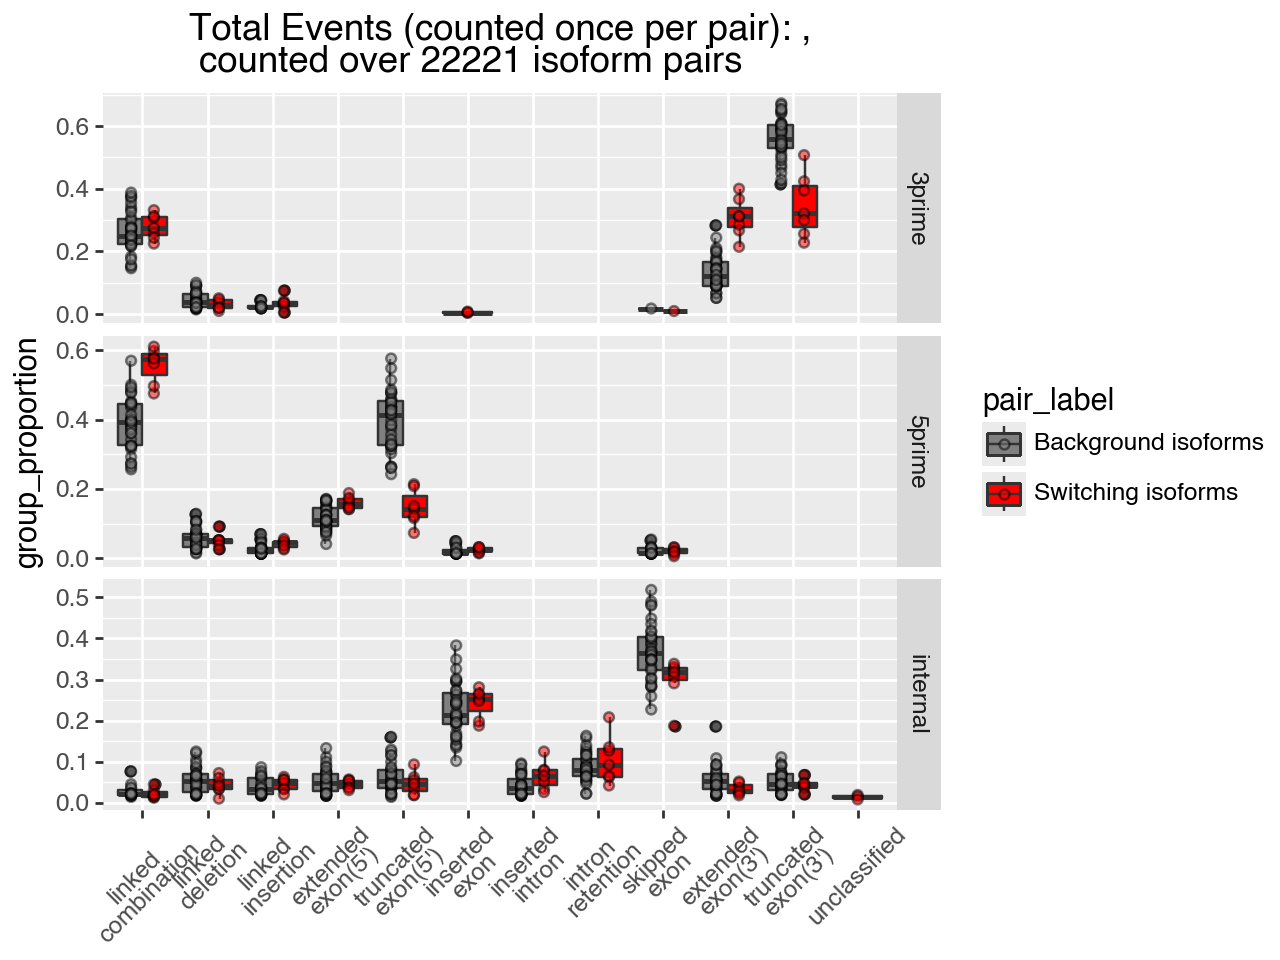

In [43]:
# Create factor with custom order
event_names_order = ['linked\ncombination', 'linked\ndeletion', 'linked\ninsertion', "extended\nexon(5')", "truncated\nexon(5')",
                     'inserted\nexon', 'inserted\nintron', 'intron\nretention',
                     'skipped\nexon', "extended\nexon(3')", "truncated\nexon(3')", "unclassified"]
prop_df['event_name_ordered'] = pd.Categorical(
    prop_df['truncated_linked_event_name_x'], categories=event_names_order)


p9.ggplot(data=prop_df, mapping=p9.aes(x='event_name_ordered', y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + p9.theme(axis_text_x=p9.element_text(angle=45)) + \
    p9.labs(title="Total Events (counted once per pair): " +
            ",\n counted over " +
            str(collect_results.shape[0]) + " isoform pairs", x="") + p9.scale_fill_manual(["grey", "red"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(width=0.7)) + p9.facet_grid(rows="truncated_linked_edge_label", scales="free")

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/5prime_proportions.png


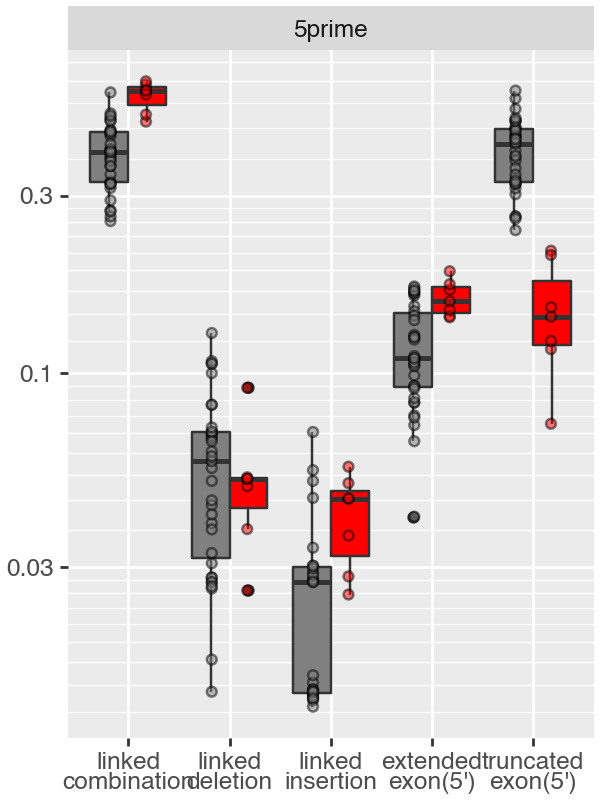

In [44]:
# Create factor with custom order
event_names_order = ['linked\ncombination', 'linked\ndeletion', 'linked\ninsertion', "extended\nexon(5')", "truncated\nexon(5')",
                     'inserted\nexon', 'inserted\nintron', 'intron\nretention',
                     'skipped\nexon', "extended\nexon(3')", "truncated\nexon(3')"]
prop_df['event_name_ordered'] = pd.Categorical(
    prop_df['truncated_linked_event_name_x'], categories=event_names_order)
filtered_prop_df = prop_df.loc[prop_df.group_proportion > 0.1]


fig3f_a = p9.ggplot(data=prop_df[(prop_df.event_name_ordered.isin(['linked\ncombination', 'linked\ndeletion', 'linked\ninsertion', "extended\nexon(5')", "truncated\nexon(5')"])) & (prop_df.truncated_linked_edge_label == "5prime")], mapping=p9.aes(x="event_name_ordered", y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + \
    p9.labs(x="", y="") + p9.scale_fill_manual(["grey", "red", "orange"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(
        width=0.7)) + p9.facet_grid(cols="truncated_linked_edge_label", scales="free")+p9.theme(legend_position='none', figure_size=[3, 4]) + p9.scale_y_log10()


fig3f_a.save(project_path+publication_figures + "figure3/"
             + "5prime_proportions.png", dpi=600, width=3, height=4)
fig3f_a

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 3 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/3prime_proportions.png


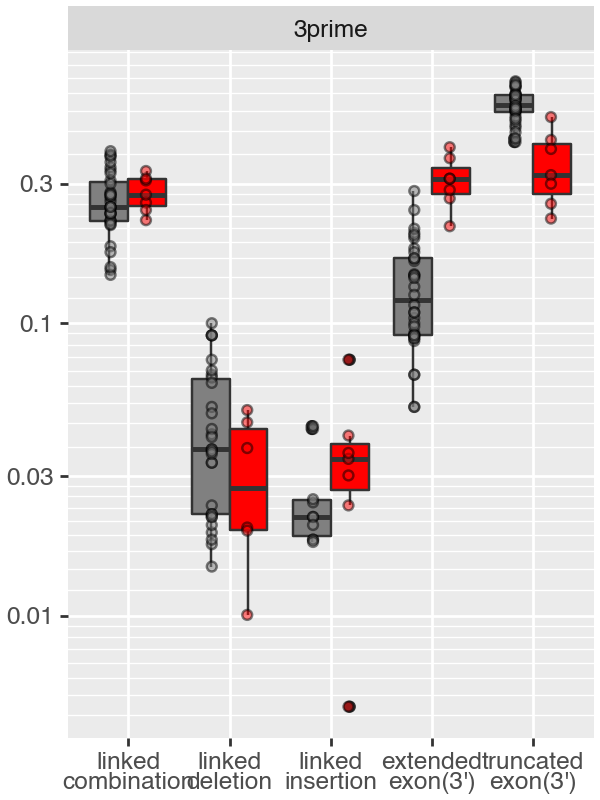

In [45]:
fig3f_b = p9.ggplot(data=prop_df[(prop_df.event_name_ordered.isin(['linked\ncombination', 'linked\ndeletion', 'linked\ninsertion', "extended\nexon(3')", "truncated\nexon(3')"])) & (prop_df.truncated_linked_edge_label == "3prime")], mapping=p9.aes(x="event_name_ordered", y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + \
    p9.labs(x="", y="") + p9.scale_fill_manual(["grey", "red", "orange"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(
        width=0.7)) + p9.facet_grid(cols="truncated_linked_edge_label", scales="free")+p9.theme(legend_position='none')+p9.theme(legend_position='none', figure_size=[3, 4]) + p9.scale_y_log10()

fig3f_b.save(project_path+publication_figures + "figure3/"
             + "3prime_proportions.png", dpi=600, width=3, height=4)
fig3f_b

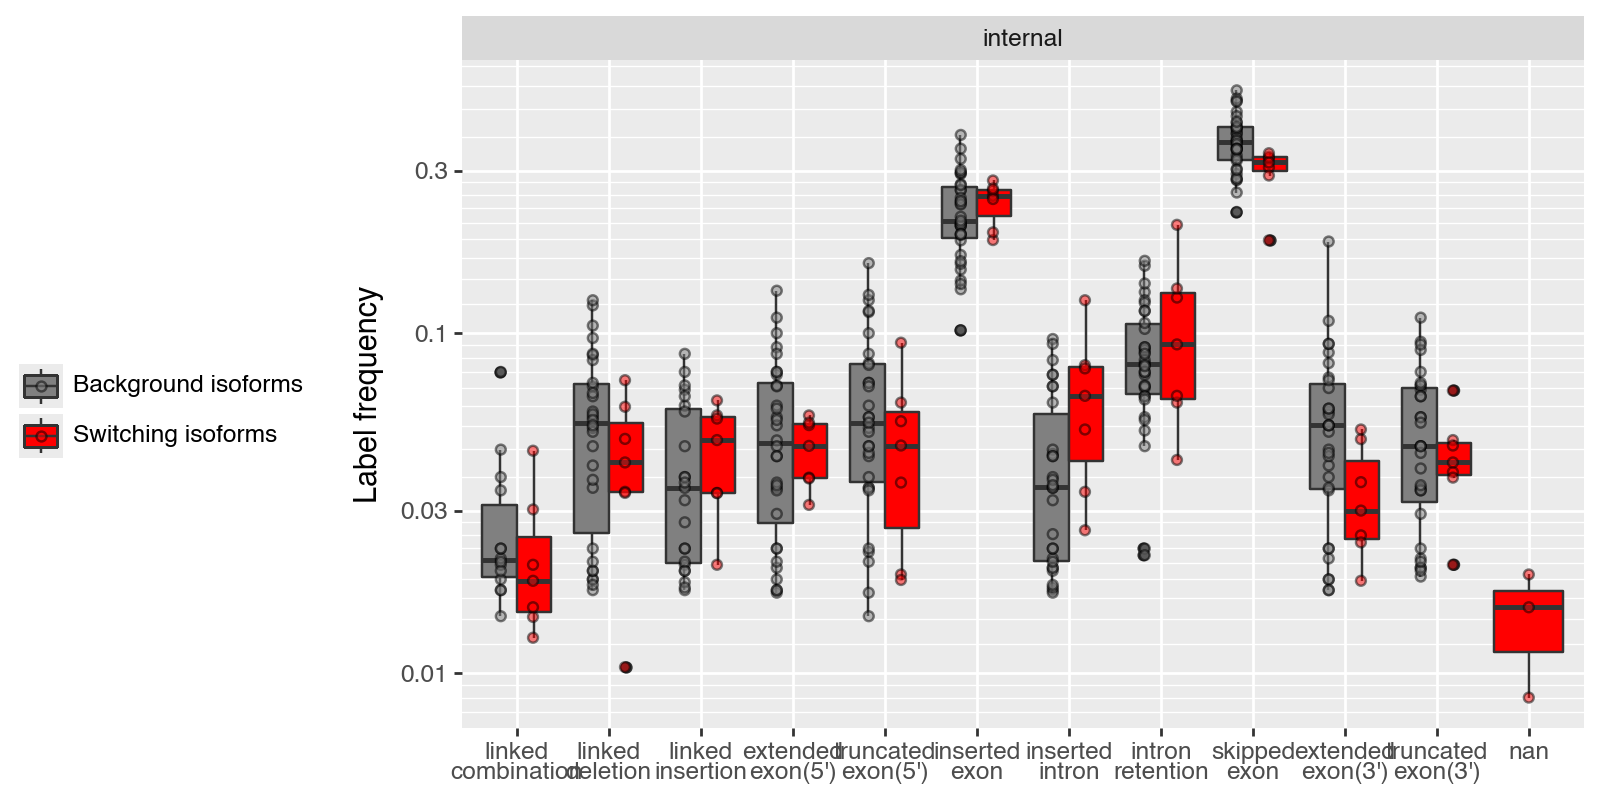

In [46]:


# Save with ggsave

fig3f_c = p9.ggplot(data=prop_df[(prop_df.truncated_linked_edge_label == "internal")], mapping=p9.aes(x="event_name_ordered", y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + \
    p9.labs(x="", fill="", y="Label frequency") + p9.scale_fill_manual(["grey", "red", "orange"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(
        width=0.7)) + p9.facet_grid(cols="truncated_linked_edge_label", scales="free") + p9.theme(legend_position='left', figure_size=[8, 4]) + p9.scale_y_log10()  # Remove legend


fig3f_c

# p9.theme(axis_text_x=p9.element_text(angle=45)) + \

In [47]:
prop_df[(prop_df.truncated_linked_edge_label == "internal")
        & (prop_df.event_name_ordered.isna())]

,sample_id,pair_label,truncated_linked_edge_label,truncated_linked_event_name_x,gene_id_x,feature_iddRNA_x,feature_idcDNA_x,chrdRNA_x,stranddRNA_x,starts_npdRNA_x,...,bin_y,left_y,right_y,mid_y,counts_y,proportions_y,sample_y,truncated_linked_event_name_y,group_proportion,event_name_ordered
24,sample_00_A549,Switching isoforms,internal,unclassified,4,4,4,4,4,4,...,0,0,0,0,0,0,205,205,0.019512,NaN
49,sample_00_H9,Switching isoforms,internal,unclassified,3,3,3,3,3,3,...,0,0,0,0,0,0,192,192,0.015625,NaN
73,sample_00_HEYA8,Switching isoforms,internal,unclassified,2,2,2,2,2,2,...,0,0,0,0,0,0,236,236,0.008475,NaN


The 'nan' labels above seem to be coming from only three unclassified pairs (see above df).
These are therefore removed from the final figure below.

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure3/internal_proportions.png


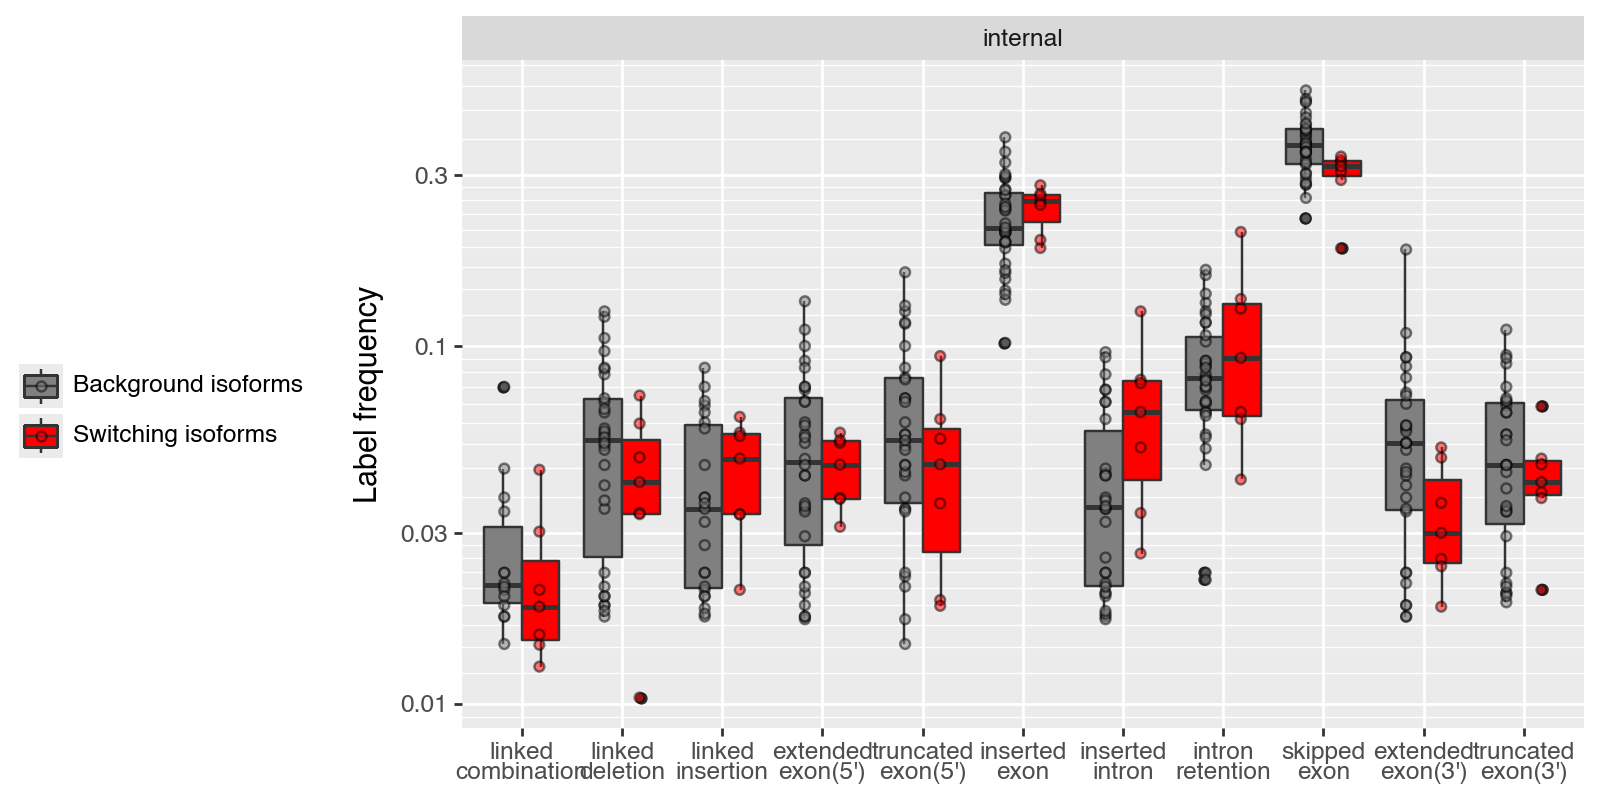

In [48]:


fig3f_c = p9.ggplot(data=prop_df[(prop_df.event_name_ordered.isin(ORDER_EVENTS)) & (prop_df. truncated_linked_edge_label == "internal")], mapping=p9.aes(x="event_name_ordered", y="group_proportion", fill="pair_label")) + \
    p9.geom_boxplot(position="dodge") + \
    p9.labs(x="", fill="", y="Label frequency") + p9.scale_fill_manual(["grey", "red", "orange"]) + p9.geom_jitter(alpha=0.5, position=p9.position_dodge(
        width=0.7)) + p9.facet_grid(cols="truncated_linked_edge_label", scales="free") + p9.theme(legend_position='left', figure_size=[8, 4]) + p9.scale_y_log10()  # Remove legend


fig3f_c.save(project_path+publication_figures + "figure3/"
             + "internal_proportions.png", dpi=600, width=8, height=4)
fig3f_c